# Soft-Margin SVM Classifier

This notebook implements a **Soft-Margin SVM** classifier with:
- ✅ **Complete Soft-Margin SVM implementation** using CVXOPT QP solver
- ✅ **One-vs-One multiclass classification** strategy
- ✅ **Comprehensive visualizations**: Confusion Matrix, Metrics Charts, Feature Analysis

## Features:
- Linear and RBF kernel support (automatically selects based on dataset size)
- Memory-efficient SMOTE implementation
- Feature scaling with StandardScaler
- Comprehensive error handling and memory limits
- Rich visualizations and performance metrics




In [1]:
# ==============================================================
# Soft-Margin SVM Implementation - Memory Optimized
# ==============================================================
import numpy as np
import cvxopt
import cvxopt.solvers

# Configure cvxopt for memory efficiency
cvxopt.solvers.options['show_progress'] = False
cvxopt.solvers.options['maxiters'] = 200  # Increased for better convergence
cvxopt.solvers.options['feastol'] = 1e-6  # Slightly relaxed for memory
cvxopt.solvers.options['abstol'] = 1e-6
cvxopt.solvers.options['reltol'] = 1e-6

class SoftMarginSVM:
    """
    Soft-Margin SVM for binary classification using CVXOPT QP solver.
    Memory-optimized implementation.
    """

    def __init__(self, C=0.1, kernel='linear', gamma=None, degree=3, coef0=0.0, verbose=False):
        """
        Parameters:
        -----------
        C : float, default=0.1
            Regularization parameter. Smaller C allows more margin violations.
        kernel : str, default='linear'
            Kernel type: 'linear', 'poly', or 'rbf'
        gamma : float, default=None
            Kernel coefficient for 'rbf' and 'poly'. If None, uses 1/n_features
        degree : int, default=3
            Degree for polynomial kernel
        coef0 : float, default=0.0
            Independent term in polynomial kernel
        verbose : bool, default=False
            Whether to print progress
        """
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.verbose = verbose

        # Model parameters (set during fit)
        self.w = None
        self.b = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.dual_coef_ = None
        self.n_support_vectors_ = 0

    def _kernel_matrix(self, X1, X2):
        """Compute kernel matrix between X1 and X2"""
        if self.kernel == 'linear':
            return X1 @ X2.T
        elif self.kernel == 'poly':
            return (self.gamma * (X1 @ X2.T) + self.coef0) ** self.degree
        elif self.kernel == 'rbf':
            # RBF: exp(-gamma * ||x - y||^2)
            # Memory-efficient computation
            X1_norm = np.sum(X1**2, axis=1).reshape(-1, 1)
            X2_norm = np.sum(X2**2, axis=1).reshape(1, -1)
            distances = X1_norm + X2_norm - 2 * X1 @ X2.T
            return np.exp(-self.gamma * np.clip(distances, 0, None))
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def fit(self, X, y):
        """
        Train the SVM model.

        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Training data
        y : array-like of shape (n_samples,)
            Target values. Must be binary: {-1, 1} or {0, 1}
        """
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).ravel()

        # Convert y to {-1, 1} if needed
        unique_labels = np.unique(y)
        if len(unique_labels) != 2:
            raise ValueError("SVM requires exactly 2 classes for binary classification")

        if set(unique_labels) != {-1, 1}:
            # Map to {-1, 1}
            y = np.where(y == unique_labels[0], -1, 1)
            self.classes_ = unique_labels
            self.label_map_ = {unique_labels[0]: -1, unique_labels[1]: 1}
            self.reverse_map_ = {-1: unique_labels[0], 1: unique_labels[1]}
        else:
            self.classes_ = unique_labels
            self.label_map_ = None
            self.reverse_map_ = None

        n_samples, n_features = X.shape

        # Set gamma for RBF if not specified
        if self.kernel in ['rbf', 'poly'] and self.gamma is None:
            self.gamma = 1.0 / n_features

        if self.verbose:
            print(f"Training Soft-Margin SVM: C={self.C}, kernel={self.kernel}, n_samples={n_samples}")

        # Compute kernel matrix (memory-intensive step)
        # For large datasets, we might need to sample or use chunking
        # But for now, we'll proceed and let user know if memory issues occur
        try:
            K = self._kernel_matrix(X, X)
        except MemoryError:
            raise MemoryError(
                f"Kernel matrix too large for memory. "
                f"Consider: 1) Reducing training samples, 2) Using linear kernel, "
                f"3) Using feature selection"
            )

        # QP formulation: min (1/2) α^T P α + q^T α
        # where P = y y^T * K, q = -1
        P = cvxopt.matrix(np.outer(y, y) * K)
        q = cvxopt.matrix(-np.ones(n_samples))

        # Constraints: 0 <= α <= C, Σ α_i y_i = 0
        # G α <= h: -α <= 0  and  α <= C
        G = cvxopt.matrix(np.vstack([-np.eye(n_samples), np.eye(n_samples)]))
        h = cvxopt.matrix(np.hstack([np.zeros(n_samples), np.ones(n_samples) * self.C]))

        # A α = b: Σ α_i y_i = 0
        A = cvxopt.matrix(y.reshape(1, -1), tc='d')
        b = cvxopt.matrix(0.0)

        # Solve QP
        if self.verbose:
            print("  Solving QP problem...")
        sol = cvxopt.solvers.qp(P, q, G, h, A, b)

        if sol['status'] != 'optimal':
            if self.verbose:
                print(f"  Warning: QP status: {sol['status']}")
            # Try with relaxed tolerances
            if sol['status'] == 'unknown':
                # May still be usable
                pass
            else:
                raise RuntimeError(f"QP solver failed: {sol['status']}")

        # Extract solution
        alphas = np.ravel(sol['x'])

        # Find support vectors (α > tolerance)
        sv_threshold = 1e-5
        sv_mask = alphas > sv_threshold
        self.n_support_vectors_ = sv_mask.sum()

        if self.verbose:
            print(f"  Support vectors: {self.n_support_vectors_} / {n_samples}")

        # Store support vectors and dual coefficients
        self.support_vectors_ = X[sv_mask]
        self.support_vector_labels_ = y[sv_mask]
        self.dual_coef_ = alphas[sv_mask] * y[sv_mask]

        # Compute w (only for linear kernel, otherwise use kernel trick)
        if self.kernel == 'linear':
            self.w = (alphas[sv_mask] * y[sv_mask]) @ self.support_vectors_
        else:
            self.w = None  # Use kernel trick for prediction

        # Compute bias b
        # Use margin support vectors where 0 < α < C
        margin_mask = (alphas > sv_threshold) & (alphas < self.C - sv_threshold)
        if margin_mask.any():
            if self.kernel == 'linear':
                b_values = y[margin_mask] - (X[margin_mask] @ self.w)
            else:
                # For non-linear: b = y - Σ α_j y_j K(x_j, x_i)
                b_values = []
                for idx in np.where(margin_mask)[0]:
                    k_values = self._kernel_matrix(X[[idx]], self.support_vectors_)
                    b_val = y[idx] - (self.dual_coef_ @ k_values.T).item()
                    b_values.append(b_val)
                b_values = np.array(b_values)
            self.b = np.mean(b_values)
        else:
            # Fallback: use any support vector
            if self.kernel == 'linear':
                self.b = y[sv_mask][0] - (self.support_vectors_[0] @ self.w)
            else:
                k_val = self._kernel_matrix(self.support_vectors_[[0]], self.support_vectors_)
                self.b = self.support_vector_labels_[0] - (self.dual_coef_ @ k_val.T).item()

        # Store training data for prediction (needed for non-linear kernels)
        if self.kernel != 'linear':
            self.X_train_ = X

        return self

    def predict(self, X):
        """
        Predict class labels for samples in X.

        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Samples to predict

        Returns:
        --------
        y_pred : array of shape (n_samples,)
            Predicted class labels
        """
        X = np.asarray(X, dtype=np.float64)

        if self.kernel == 'linear':
            # Linear: f(x) = w·x + b
            decisions = X @ self.w + self.b
        else:
            # Non-linear: f(x) = Σ α_i y_i K(x_i, x) + b
            K = self._kernel_matrix(X, self.support_vectors_)
            decisions = (self.dual_coef_ @ K.T) + self.b

        # Predict classes
        y_pred = np.sign(decisions)

        # Map back to original labels if needed
        if self.reverse_map_ is not None:
            y_pred = np.where(y_pred == -1,
                            self.reverse_map_[-1],
                            self.reverse_map_[1])
        else:
            # Ensure labels match original
            y_pred = np.where(y_pred == -1, self.classes_[0], self.classes_[1])

        return y_pred.astype(int)

    def score(self, X, y):
        """Return mean accuracy"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [2]:
# One-vs-One Multiclass Classifier
from itertools import combinations
from scipy.stats import mode
from tqdm import tqdm

class OneVsOneClassifier:
    """
    One-vs-One multiclass classifier wrapper.
    Memory-optimized for large datasets.
    """

    def __init__(self, estimator, n_jobs=1, verbose=False):
        """
        Parameters:
        -----------
        estimator : object
            Binary classifier with fit() and predict() methods
        n_jobs : int, default=1
            Number of parallel jobs. Use 1 for memory efficiency.
        verbose : bool, default=False
            Whether to print progress
        """
        self.estimator = estimator
        self.n_jobs = n_jobs
        self.verbose = verbose
        self.estimators_ = []
        self.classes_ = None

    def fit(self, X, y):
        """
        Fit one-vs-one classifiers.

        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Training data
        y : array-like of shape (n_samples,)
            Target values
        """
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        if n_classes < 2:
            raise ValueError("Need at least 2 classes")

        # Generate all pairs of classes
        class_pairs = list(combinations(self.classes_, 2))
        n_pairs = len(class_pairs)

        if self.verbose:
            print(f"Training {n_pairs} binary classifiers for {n_classes} classes...")

        self.estimators_ = []

        for i, (class1, class2) in enumerate(class_pairs):
            if self.verbose:
                print(f"  [{i+1}/{n_pairs}] Training classifier for classes {class1} vs {class2}...")

            # Get data for this pair
            mask = (y == class1) | (y == class2)
            X_pair = X[mask]
            y_pair = y[mask]

            if self.verbose:
                print(f"    Samples: {len(X_pair)} (class {class1}: {(y_pair == class1).sum()}, "
                      f"class {class2}: {(y_pair == class2).sum()})")

            # Create and train estimator
            # For SoftMarginSVM, we need to create a new instance
            if isinstance(self.estimator, SoftMarginSVM):
                estimator = SoftMarginSVM(
                    C=self.estimator.C,
                    kernel=self.estimator.kernel,
                    gamma=self.estimator.gamma,
                    degree=self.estimator.degree,
                    coef0=self.estimator.coef0,
                    verbose=False  # Disable verbose for individual classifiers
                )
            else:
                # For other estimators, try to clone
                from copy import deepcopy
                try:
                    estimator = deepcopy(self.estimator)
                except:
                    # Fallback: create new instance
                    estimator = type(self.estimator)(**self.estimator.get_params()
                                                     if hasattr(self.estimator, 'get_params')
                                                     else {})

            # Train
            estimator.fit(X_pair, y_pair)
            self.estimators_.append((class1, class2, estimator))

            if self.verbose:
                print(f"    ✓ Completed")

        return self

    def predict(self, X):
        """
        Predict class labels using one-vs-one voting.

        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Samples to predict

        Returns:
        --------
        y_pred : array of shape (n_samples,)
            Predicted class labels
        """
        X = np.asarray(X)
        n_samples = X.shape[0]

        # Collect predictions from all binary classifiers
        predictions = np.zeros((len(self.estimators_), n_samples), dtype=int)

        for i, (class1, class2, estimator) in enumerate(self.estimators_):
            pred = estimator.predict(X)
            # Map predictions to class indices for voting
            predictions[i] = np.where(pred == class1,
                                     np.where(self.classes_ == class1)[0][0],
                                     np.where(self.classes_ == class2)[0][0])

        # Majority voting
        y_pred = mode(predictions, axis=0, keepdims=False).mode

        # Map back to original class labels
        return self.classes_[y_pred]

    def score(self, X, y):
        """Return mean accuracy"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


In [3]:
# Platform detection and data loading for Google Colab
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
import joblib
import os
import sys

# Platform detection
def detect_platform():
    """Detect the current platform (Colab, Kaggle, or Local)"""
    try:
        import google.colab
        return "Google Colab", True, False, False
    except ImportError:
        pass

    if os.path.exists('/kaggle/input'):
        return "Kaggle", False, True, False

    return "Local", False, False, True

PLATFORM, IS_COLAB, IS_KAGGLE, IS_LOCAL = detect_platform()
print(f"🌍 Platform detected: {PLATFORM}")

# Custom SMOTE implementation (memory-efficient, avoids dependency issues)
class SimpleSMOTE:
    """Simple SMOTE implementation with memory optimization"""
    def __init__(self, k_neighbors=5, random_state=42, sampling_strategy='auto', max_samples_per_class=None):
        self.k = k_neighbors
        self.random_state = np.random.RandomState(random_state)
        self.sampling_strategy = sampling_strategy
        self.max_samples_per_class = max_samples_per_class  # Limit max samples per class

    def fit_resample(self, X, y):
        X = np.asarray(X, dtype=np.float32)  # Use float32 to save memory
        y = np.asarray(y)
        classes, counts = np.unique(y, return_counts=True)
        max_count = counts.max()

        # Limit max samples if specified (for memory efficiency)
        if self.max_samples_per_class is not None:
            max_count = min(max_count, self.max_samples_per_class)
            print(f"  Limiting to {max_count} samples per class for memory efficiency")

        X_resampled = [X]
        y_resampled = [y]

        for cls, count in zip(classes, counts):
            X_cls = X[y == cls]
            if count < max_count:
                n_samples_needed = max_count - count
                synthetic_samples = self._generate_samples(X_cls, n_samples_needed)
                X_resampled.append(synthetic_samples.astype(np.float32))
                y_resampled.append(np.full(n_samples_needed, cls))

        X_res = np.vstack(X_resampled).astype(np.float32)
        y_res = np.concatenate(y_resampled)
        return X_res, y_res

    def _generate_samples(self, X, n_samples):
        n_minority = len(X)
        if n_minority == 0:
            return np.empty((0, X.shape[1]), dtype=np.float32)
        k = min(self.k, n_minority - 1)
        synthetic = []
        for _ in range(n_samples):
            i = self.random_state.randint(0, n_minority)
            xi = X[i]
            distances = np.sqrt(((X - xi)**2).sum(axis=1))
            nn_indices = np.argsort(distances)[1:k+1]
            nn = X[self.random_state.choice(nn_indices)]
            diff = nn - xi
            gap = self.random_state.rand()
            synthetic.append(xi + gap * diff)
        return np.array(synthetic, dtype=np.float32)

# Load and prepare data
print("\n" + "="*80)
print("DATA LOADING AND PREPROCESSING")
print("="*80)

# Re-detect platform if needed
try:
    _ = IS_COLAB, IS_KAGGLE, IS_LOCAL
except NameError:
    PLATFORM, IS_COLAB, IS_KAGGLE, IS_LOCAL = detect_platform()

data = None

if IS_COLAB:
    # Google Colab environment
    print("\n📁 Google Colab environment detected")

    # Try multiple methods to load data
    data_loaded = False

    # Method 1: Check if file is already uploaded
    for filename in ['city_day.csv', 'city_day_dataset.csv']:
        if os.path.exists(f'/content/{filename}'):
            print(f"   Loading from /content/{filename}")
            data = pd.read_csv(f'/content/{filename}')
            data_loaded = True
            break

    # Method 2: Check Google Drive
    if not data_loaded and os.path.exists('/content/drive'):
        print("   Checking Google Drive...")
        for root, dirs, files in os.walk('/content/drive/MyDrive'):
            for filename in files:
                if filename in ['city_day.csv', 'city_day_dataset.csv']:
                    filepath = os.path.join(root, filename)
                    print(f"   Loading from Google Drive: {filepath}")
                    data = pd.read_csv(filepath)
                    data_loaded = True
                    break
            if data_loaded:
                break

    # Method 3: File uploader
    if not data_loaded:
        print("   ⚠️  Dataset file not found. Please upload your dataset.")
        try:
            from google.colab import files
            print("\n   📤 Upload dataset file (city_day.csv or city_day_dataset.csv):")
            uploaded = files.upload()
            for filename in uploaded.keys():
                if filename.endswith('.csv'):
                    print(f"   ✅ Uploaded: {filename}")
                    data = pd.read_csv(filename)
                    data_loaded = True
                    break
        except ImportError:
            print("   ⚠️  File uploader not available.")

    if not data_loaded:
        raise FileNotFoundError(
            "Dataset file not found. Please upload city_day.csv or city_day_dataset.csv"
        )
elif IS_KAGGLE:
    # Kaggle environment (not recommended, but keep for compatibility)
    print("\n📁 Kaggle environment detected")
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if filename.endswith('.csv'):
                filepath = os.path.join(dirname, filename)
                print(f"   Loading: {filepath}")
                data = pd.read_csv(filepath)
                break
        if data is not None:
            break
else:
    # Local environment
    print("\n📁 Local environment detected")
    try:
        data = pd.read_csv("city_day.csv")
        print("   ✅ Loaded: city_day.csv")
    except FileNotFoundError:
        try:
            data = pd.read_csv("city_day_dataset.csv")
            print("   ✅ Loaded: city_day_dataset.csv")
        except FileNotFoundError:
            raise FileNotFoundError("Dataset file not found")

print(f"✓ Dataset loaded: {data.shape}")

# Convert Date to datetime
print("✓ Processing Date column...")
data['Date'] = pd.to_datetime(data['Date'])

# Handle missing values - Memory efficient approach
print("\n✓ Processing missing values...")

# Fill numeric columns with median (more memory efficient than dropping)
numeric_columns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
                   'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

print("  Filling missing numeric values with median...")
for col in numeric_columns:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

# 2️⃣ Fill missing categorical value for AQI_Bucket
if 'AQI_Bucket' in data.columns:
    print("  Filling missing AQI_Bucket values with 'Moderate'...")
    data['AQI_Bucket'] = data['AQI_Bucket'].fillna('Moderate')

# 3️⃣ Check remaining missing values
print(f"  Missing values after handling: {data.isnull().sum().sum()}")

# Encode categorical variables using LabelEncoder (as in reference notebook)
print("✓ Encoding categorical variables...")
le = LabelEncoder()
city_encoder = LabelEncoder()

# Encode City
data['City'] = city_encoder.fit_transform(data['City'].astype(str))
print(f"  Number of unique cities: {len(city_encoder.classes_)}")

# Encode target (AQI_Bucket)
data['AQI_Bucket'] = le.fit_transform(data['AQI_Bucket'].astype(str))
print(f"  Classes: {le.classes_}")

# Prepare features (as in reference notebook)
# Include: City and all pollutant columns
# NOTE: AQI is NOT included as a feature because:
#   - AQI_Bucket (target) is directly derived from AQI
#   - Including AQI would cause data leakage (model could trivially predict AQI_Bucket)
#   - In real-world scenarios, we predict AQI_Bucket from pollutants, not from AQI itself
# Drop Date column (not used in reference notebook)
print("✓ Preparing features...")
print("  ⚠️  Excluding AQI from features to avoid data leakage (AQI_Bucket is derived from AQI)")
feature_columns = ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
                   'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

# Only include columns that exist in the dataset
feature_columns = [col for col in feature_columns if col in data.columns]

X = data[feature_columns].values
y = data['AQI_Bucket'].values

print(f"  Feature columns: {feature_columns}")
print(f"  Total features: {len(feature_columns)}")

# Split dataset (test_size=0.3 as in reference notebook)
print("✓ Splitting dataset...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(f"  Classes and number of values in trainset: {Counter(y_train)}")

# Apply SMOTE for data balancing with memory limits
print("\n✓ Applying SMOTE for data balancing...")
print("  ⚠️  Memory optimization: Limiting max samples per class")

# Estimate available memory and set limits
# Colab free tier has ~12-15GB RAM
# Limit training samples to avoid memory issues
MAX_SAMPLES_PER_CLASS = 5000  # Adjust based on available memory

smote = SimpleSMOTE(
    random_state=42,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    k_neighbors=5
)

try:
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print(f"  ✓ SMOTE applied successfully")
except MemoryError:
    print(f"  ⚠️  SMOTE failed due to memory. Using original data...")
    X_train_smote, y_train_smote = X_train, y_train

# Convert to float32 to save memory
X_train_smote = X_train_smote.astype(np.float32)
X_test = X_test.astype(np.float32)

print(f"  Classes after SMOTE: {Counter(y_train_smote)}")

# Scale features for SVM (important for convergence and memory efficiency)
print("\n✓ Scaling features (StandardScaler)...")
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
print("  ✓ Features scaled")

# Memory optimization: Further reduce dataset if too large
# SVM kernel matrix is O(n^2), so we need to limit samples
MAX_TRAIN_SAMPLES = 8000  # Limit for kernel matrix memory

if len(X_train_smote) > MAX_TRAIN_SAMPLES:
    print(f"\n⚠️  Training set too large ({len(X_train_smote)} samples)")
    print(f"   Limiting to {MAX_TRAIN_SAMPLES} samples for memory efficiency...")
    # Stratified sampling
    from sklearn.model_selection import train_test_split
    X_train_smote, _, y_train_smote, _ = train_test_split(
        X_train_smote, y_train_smote,
        train_size=MAX_TRAIN_SAMPLES,
        random_state=42,
        stratify=y_train_smote
    )
    print(f"   ✓ Reduced to {len(X_train_smote)} samples")

print("\n" + "="*80)
print("✅ DATA PREPARATION COMPLETE")
print("="*80)
print(f"  Train samples: {X_train_smote.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Features: {X_train_smote.shape[1]}")
print(f"  Feature columns: {feature_columns}")
print(f"  Target: AQI_Bucket (derived from AQI)")
print(f"  ⚠️  AQI excluded from features to prevent data leakage")
print(f"  Classes: {le.classes_}")
print(f"  Number of classes: {len(le.classes_)}")
print(f"  Cities: {len(city_encoder.classes_)} unique cities")
print(f"  Memory optimization: Using float32, limited samples")
print("="*80 + "\n")


🌍 Platform detected: Google Colab

DATA LOADING AND PREPROCESSING

📁 Google Colab environment detected
   Loading from /content/city_day_dataset.csv
✓ Dataset loaded: (29531, 16)
✓ Processing Date column...

✓ Processing missing values...
  Filling missing numeric values with median...
  Filling missing AQI_Bucket values with 'Moderate'...
  Missing values after handling: 0
✓ Encoding categorical variables...
  Number of unique cities: 26
  Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']
✓ Preparing features...
  ⚠️  Excluding AQI from features to avoid data leakage (AQI_Bucket is derived from AQI)
  Feature columns: ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
  Total features: 13
✓ Splitting dataset...
  Classes and number of values in trainset: Counter({np.int64(1): 9393, np.int64(3): 5799, np.int64(2): 1940, np.int64(5): 1634, np.int64(4): 957, np.int64(0): 948})

✓ Applying SMOTE for data balancing.


TRAINING SOFT-MARGIN SVM MODEL

📊 Training Configuration:
  Training samples: 8000
  Number of classes: 6
  Number of binary classifiers: 15
  Kernel: Linear (chosen for memory efficiency)
  ⚠️  Using linear kernel to avoid memory issues with large datasets
  C (regularization): 0.1
  Strategy: One-vs-One multiclass

🚀 Starting training...
  This will train 15 binary classifiers
  Estimated time: 30-75 minutes (depending on dataset size)
Training 15 binary classifiers for 6 classes...
  [1/15] Training classifier for classes 0 vs 1...
    Samples: 3272 (class 0: 1137, class 1: 2135)
    ✓ Completed
  [2/15] Training classifier for classes 0 vs 2...
    Samples: 2274 (class 0: 1137, class 2: 1137)
    ✓ Completed
  [3/15] Training classifier for classes 0 vs 3...
    Samples: 2455 (class 0: 1137, class 3: 1318)
    ✓ Completed
  [4/15] Training classifier for classes 0 vs 4...
    Samples: 2273 (class 0: 1137, class 4: 1136)
    ✓ Completed
  [5/15] Training classifier for classes 0 vs

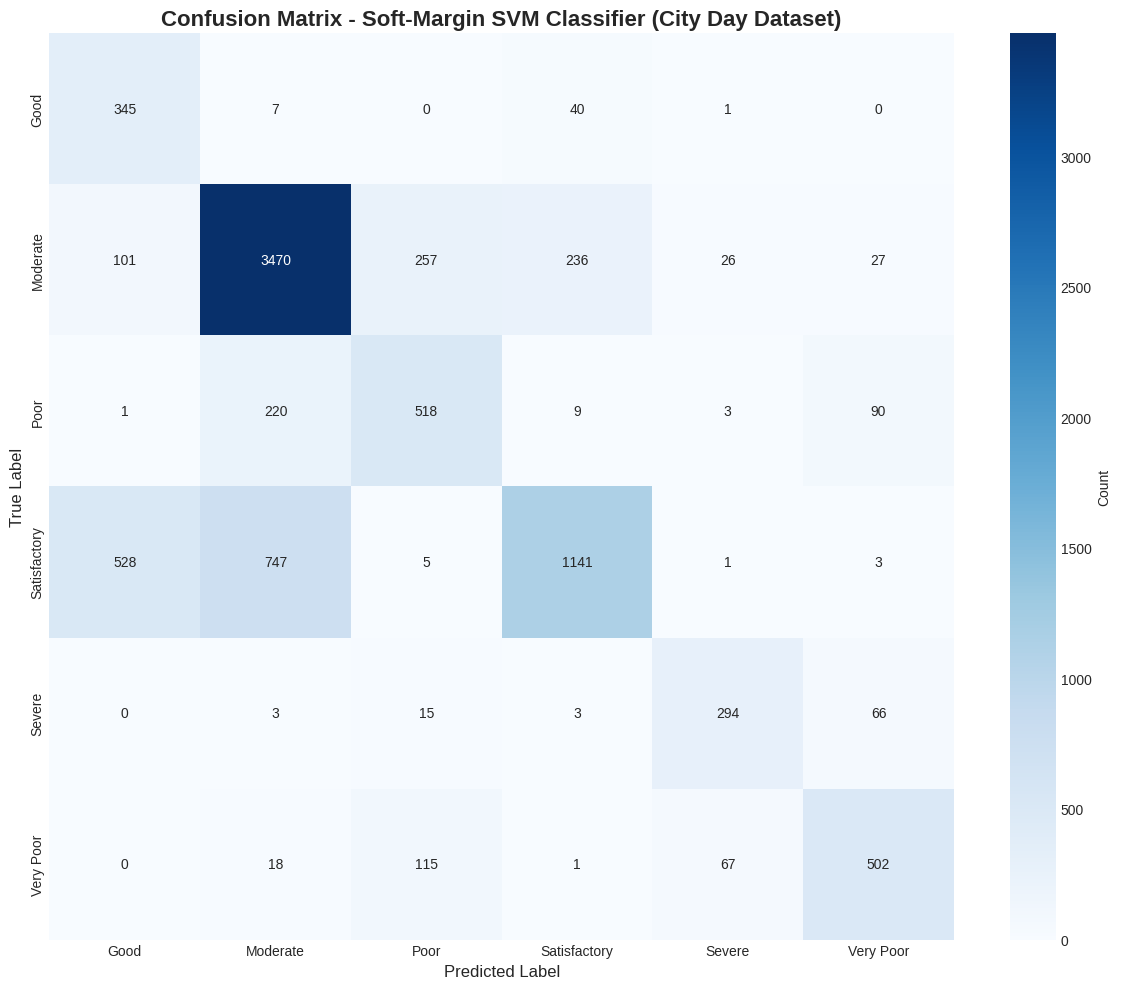

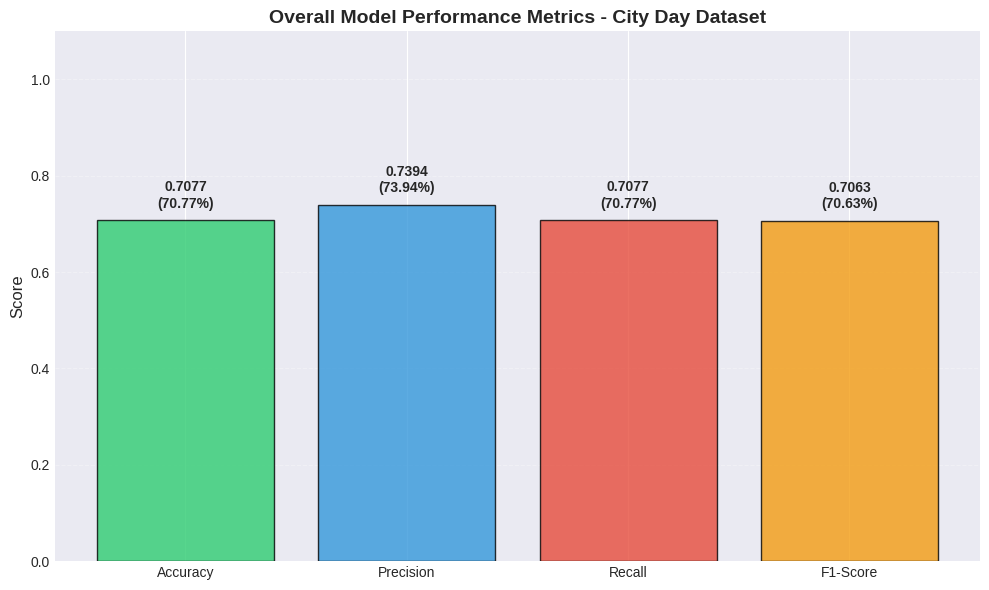

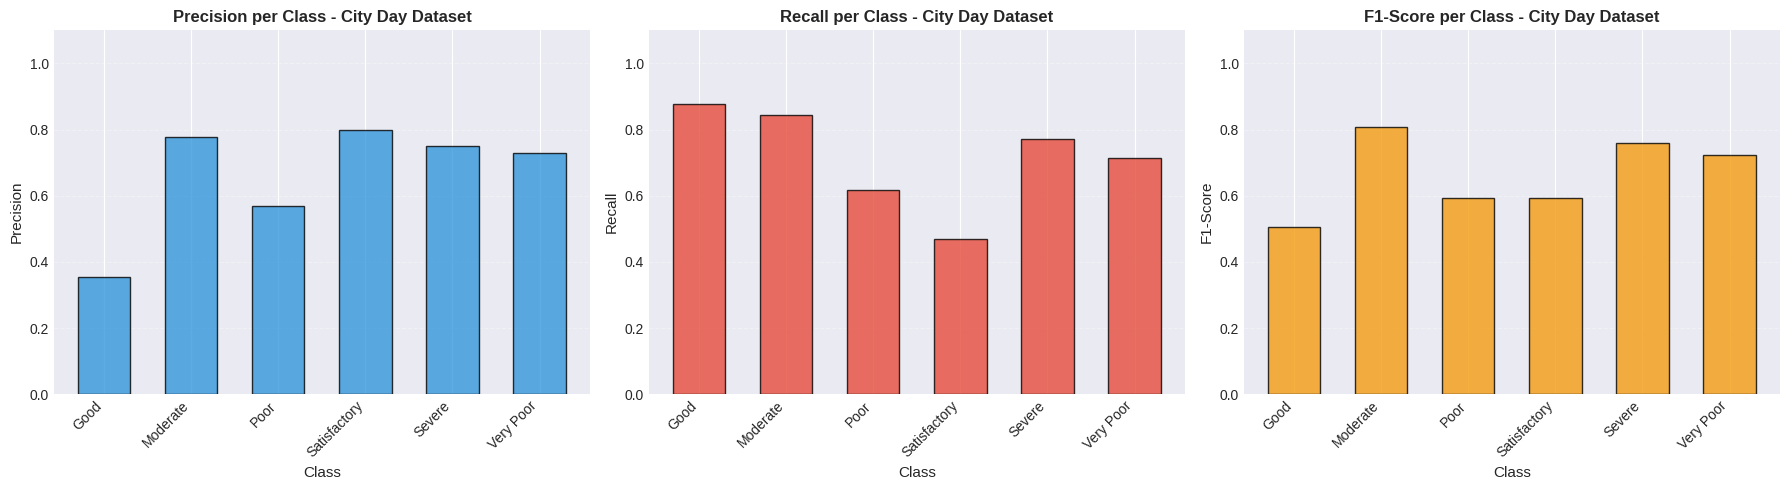

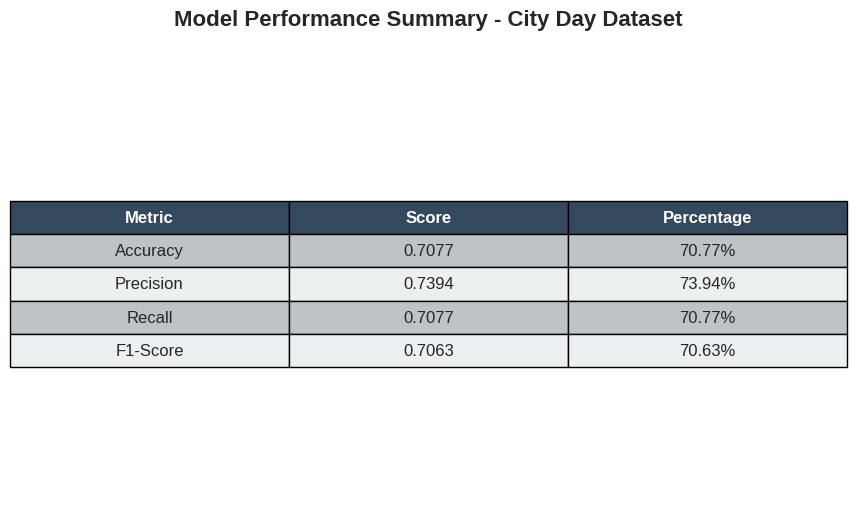

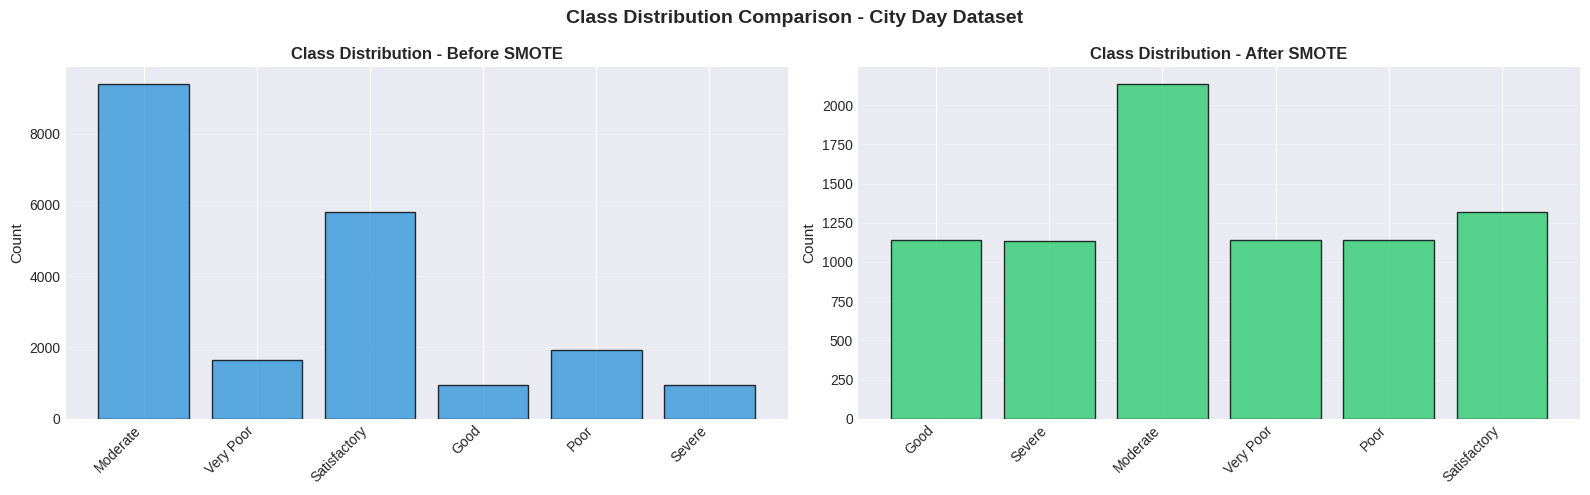

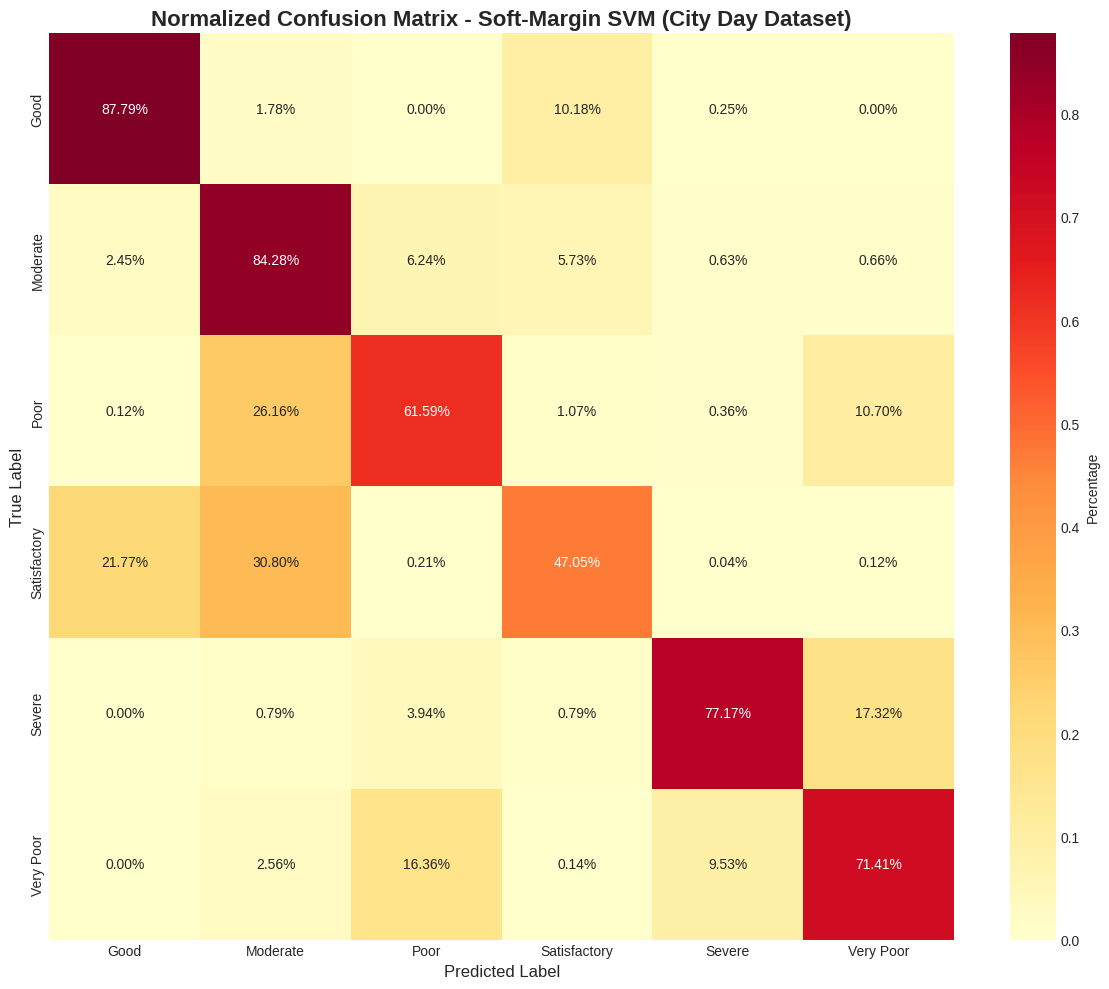

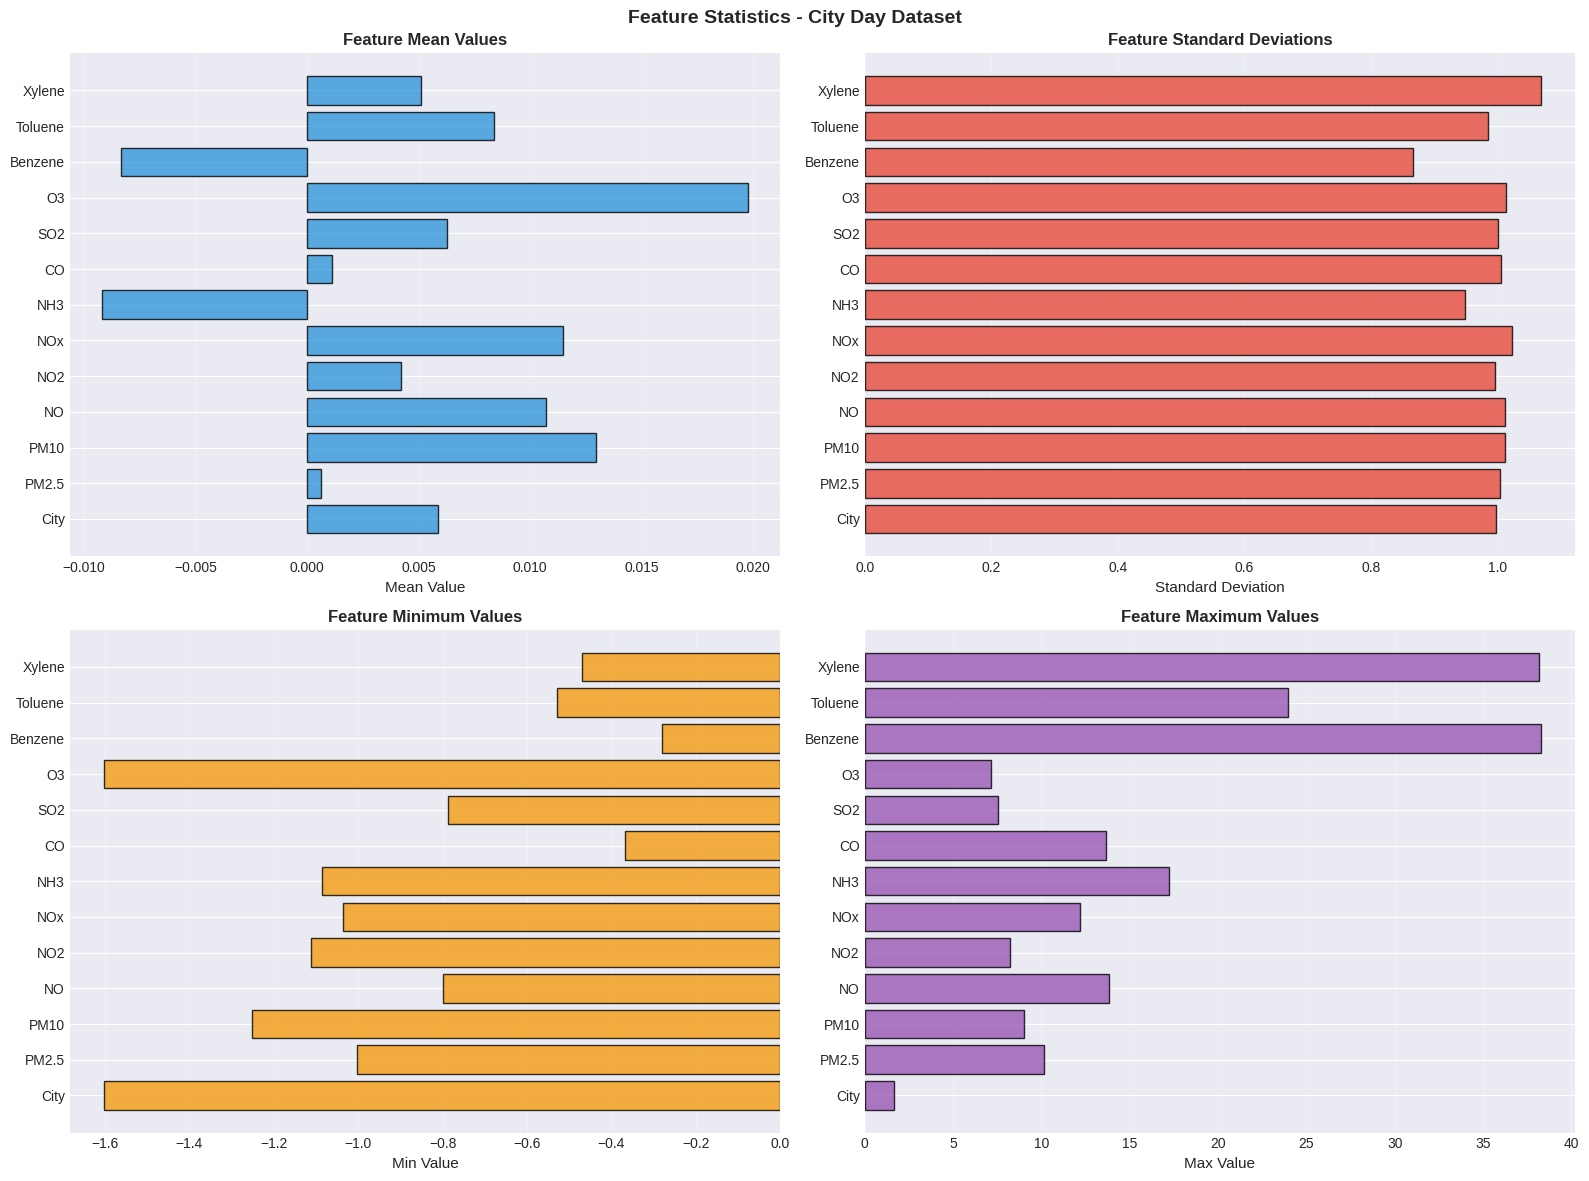


✅ EVALUATION COMPLETE - CITY DAY DATASET


In [4]:
# Train the SVM model with One-vs-One multiclass classification
print("\n" + "="*80)
print("TRAINING SOFT-MARGIN SVM MODEL")
print("="*80)

# Memory-efficient training: Use linear kernel for large datasets
# RBF kernel creates O(n^2) kernel matrix which is memory-intensive
n_samples = len(X_train_smote)
n_classes = len(np.unique(y_train_smote))
n_pairs = n_classes * (n_classes - 1) // 2

print(f"\n📊 Training Configuration:")
print(f"  Training samples: {n_samples}")
print(f"  Number of classes: {n_classes}")
print(f"  Number of binary classifiers: {n_pairs}")

# Choose kernel based on dataset size
# For large datasets, linear kernel is more memory-efficient
if n_samples > 5000:
    kernel_type = 'linear'
    kernel_params = {}
    print(f"  Kernel: Linear (chosen for memory efficiency)")
    print(f"  ⚠️  Using linear kernel to avoid memory issues with large datasets")
else:
    # Can use RBF for smaller datasets
    kernel_type = 'rbf'
    kernel_params = {'gamma': 0.1}  # Lower gamma = smoother decision boundary
    print(f"  Kernel: RBF (gamma={kernel_params['gamma']})")

# C parameter: smaller C = softer margin (more tolerant of misclassifications)
# Larger C = harder margin (less tolerant)
C_value = 0.1  # Start with smaller C for memory efficiency

print(f"  C (regularization): {C_value}")
print(f"  Strategy: One-vs-One multiclass")

# Create base SVM classifier
base_svm = SoftMarginSVM(
    C=C_value,
    kernel=kernel_type,
    **kernel_params,
    verbose=True
)

# Wrap in OneVsOneClassifier
model = OneVsOneClassifier(estimator=base_svm, n_jobs=1, verbose=True)

# Train the model
print(f"\n🚀 Starting training...")
print(f"  This will train {n_pairs} binary classifiers")
print(f"  Estimated time: {n_pairs * 2}-{n_pairs * 5} minutes (depending on dataset size)")

try:
    model.fit(X_train_smote, y_train_smote)
    print("\n✅ Training completed!")
except MemoryError as e:
    print(f"\n❌ Memory Error during training: {e}")
    print("  Solutions:")
    print("  1. Reduce MAX_TRAIN_SAMPLES (currently {MAX_TRAIN_SAMPLES})")
    print("  2. Use linear kernel only")
    print("  3. Reduce MAX_SAMPLES_PER_CLASS in SMOTE")
    raise
except Exception as e:
    print(f"\n❌ Error during training: {e}")
    raise

# Make predictions
print("\n📊 Making predictions on test set...")
y_pred = model.predict(X_test)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Per-class metrics
precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

print("\n" + "="*80)
print("OVERALL METRICS")
print("="*80)
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

# Create metrics table
print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)
metrics_df = pd.DataFrame({
    'Class': le.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
})
print("\n")
print(metrics_df.to_string(index=False))

# Detailed evaluation
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print("\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# ============================================================================
# VISUALIZATIONS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Visualization 1: Confusion Matrix Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Soft-Margin SVM Classifier (City Day Dataset)',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 2: Overall Metrics Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

bars = ax.bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylim([0, 1.1])
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Overall Model Performance Metrics - City Day Dataset',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{value:.4f}\n({value*100:.2f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Visualization 3: Per-Class Metrics Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_pos = np.arange(len(le.classes_))
width = 0.6

axes[0].bar(x_pos, precision_per_class, width, color='#3498db', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision per Class - City Day Dataset', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

axes[1].bar(x_pos, recall_per_class, width, color='#e74c3c', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Recall', fontsize=11)
axes[1].set_title('Recall per Class - City Day Dataset', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

axes[2].bar(x_pos, f1_per_class, width, color='#f39c12', alpha=0.8, edgecolor='black')
axes[2].set_xlabel('Class', fontsize=11)
axes[2].set_ylabel('F1-Score', fontsize=11)
axes[2].set_title('F1-Score per Class - City Day Dataset', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[2].set_ylim([0, 1.1])
axes[2].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Visualization 4: Metrics Summary Table (Visual)
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')

table_data = [
    ['Metric', 'Score', 'Percentage'],
    ['Accuracy', f'{accuracy:.4f}', f'{accuracy*100:.2f}%'],
    ['Precision', f'{precision:.4f}', f'{precision*100:.2f}%'],
    ['Recall', f'{recall:.4f}', f'{recall*100:.2f}%'],
    ['F1-Score', f'{f1:.4f}', f'{f1*100:.2f}%']
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center',
                colWidths=[0.3, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

# Style the header
for i in range(3):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style the data rows
colors_table = ['#ecf0f1', '#bdc3c7']
for i in range(1, len(table_data)):
    for j in range(3):
        table[(i, j)].set_facecolor(colors_table[i % 2])

plt.title('Model Performance Summary - City Day Dataset', fontsize=16, fontweight='bold', pad=20)
plt.show()

# Visualization 5: Class Distribution Comparison (Before/After SMOTE)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before SMOTE
y_train_counts = Counter(y_train)
axes[0].bar(range(len(y_train_counts)), list(y_train_counts.values()),
            color='#3498db', alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(y_train_counts)))
axes[0].set_xticklabels([le.classes_[i] for i in y_train_counts.keys()], rotation=45, ha='right')
axes[0].set_title('Class Distribution - Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# After SMOTE
y_train_smote_counts = Counter(y_train_smote)
axes[1].bar(range(len(y_train_smote_counts)), list(y_train_smote_counts.values()),
            color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1].set_xticks(range(len(y_train_smote_counts)))
axes[1].set_xticklabels([le.classes_[i] for i in y_train_smote_counts.keys()], rotation=45, ha='right')
axes[1].set_title('Class Distribution - After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution Comparison - City Day Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualization 6: Confusion Matrix Normalized (Percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - Soft-Margin SVM (City Day Dataset)',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 7: Feature Importance (if available) - Show feature statistics
if len(feature_columns) > 0:
    # Calculate feature statistics
    feature_stats = pd.DataFrame({
        'Feature': feature_columns,
        'Mean': X_train_smote.mean(axis=0),
        'Std': X_train_smote.std(axis=0),
        'Min': X_train_smote.min(axis=0),
        'Max': X_train_smote.max(axis=0)
    })

    # Plot feature ranges
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Mean values
    axes[0, 0].barh(range(len(feature_stats)), feature_stats['Mean'],
                    color='#3498db', alpha=0.8, edgecolor='black')
    axes[0, 0].set_yticks(range(len(feature_stats)))
    axes[0, 0].set_yticklabels(feature_stats['Feature'])
    axes[0, 0].set_xlabel('Mean Value', fontsize=11)
    axes[0, 0].set_title('Feature Mean Values', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Standard deviation
    axes[0, 1].barh(range(len(feature_stats)), feature_stats['Std'],
                    color='#e74c3c', alpha=0.8, edgecolor='black')
    axes[0, 1].set_yticks(range(len(feature_stats)))
    axes[0, 1].set_yticklabels(feature_stats['Feature'])
    axes[0, 1].set_xlabel('Standard Deviation', fontsize=11)
    axes[0, 1].set_title('Feature Standard Deviations', fontsize=12, fontweight='bold')
    axes[0, 1].grid(axis='x', alpha=0.3)

    # Min values
    axes[1, 0].barh(range(len(feature_stats)), feature_stats['Min'],
                    color='#f39c12', alpha=0.8, edgecolor='black')
    axes[1, 0].set_yticks(range(len(feature_stats)))
    axes[1, 0].set_yticklabels(feature_stats['Feature'])
    axes[1, 0].set_xlabel('Min Value', fontsize=11)
    axes[1, 0].set_title('Feature Minimum Values', fontsize=12, fontweight='bold')
    axes[1, 0].grid(axis='x', alpha=0.3)

    # Max values
    axes[1, 1].barh(range(len(feature_stats)), feature_stats['Max'],
                    color='#9b59b6', alpha=0.8, edgecolor='black')
    axes[1, 1].set_yticks(range(len(feature_stats)))
    axes[1, 1].set_yticklabels(feature_stats['Feature'])
    axes[1, 1].set_xlabel('Max Value', fontsize=11)
    axes[1, 1].set_title('Feature Maximum Values', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3)

    plt.suptitle('Feature Statistics - City Day Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE - CITY DAY DATASET")
print("="*80)

In [5]:
# Save the model
print("\n" + "="*80)
print("SAVING MODEL - CITY DAY DATASET")
print("="*80)

model_data = {
    'model': model,
    'label_encoder': le,
    'city_encoder': city_encoder,
    'scaler': scaler,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'kernel': kernel_type,
    'C': C_value,
    'kernel_params': kernel_params,
    'feature_columns': feature_columns,
    'test_size': 0.3,
    'random_state': 0,
    'dataset_name': 'City Day Dataset'
}

# Determine output path (platform-specific)
if IS_COLAB:
    output_path = '/content/svm_model_city_day.pkl'
    # Also save to Drive if mounted
    if os.path.exists('/content/drive'):
        drive_path = '/content/drive/MyDrive/svm_model_city_day.pkl'
        try:
            joblib.dump(model_data, drive_path)
            print(f"   💾 Also saved to Google Drive: {drive_path}")
        except Exception as e:
            print(f"   ⚠️  Could not save to Google Drive: {e}")
elif IS_KAGGLE:
    output_path = '/kaggle/working/svm_model_city_day.pkl'
else:
    output_path = 'svm_model_city_day.pkl'

joblib.dump(model_data, output_path)
print(f"\n💾 Model saved as '{output_path}'")

print(f"\n✅ Final Model: Soft-Margin SVM (One-vs-One) - City Day Dataset")
print(f"✅ Kernel: {kernel_type.upper()}")
if kernel_params:
    print(f"✅ Kernel parameters: {kernel_params}")
print(f"✅ C (regularization): {C_value}")
print(f"✅ Features: {X_train_smote.shape[1]} features")
print(f"  - Feature columns: {feature_columns}")
print(f"✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"✅ Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"✅ Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"✅ F1-Score: {f1:.4f} ({f1*100:.2f}%)")
print(f"✅ Number of classes: {len(le.classes_)}")
print(f"✅ Number of binary classifiers: {n_pairs}")

# Summary
print("\n" + "="*80)
print("MODEL SUMMARY - CITY DAY DATASET")
print("="*80)
print(f"Training samples: {X_train_smote.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of classes: {n_classes}")
print(f"Number of binary classifiers (One-vs-One): {n_pairs}")
print(f"Kernel type: {kernel_type}")
print(f"C parameter: {C_value}")
print(f"Test size: 30%")
print(f"Preprocessing: Median imputation, StandardScaler, SMOTE (limited)")
print(f"Memory optimization: float32, sample limits applied")
print("="*80)


SAVING MODEL - CITY DAY DATASET

💾 Model saved as '/content/svm_model_city_day.pkl'

✅ Final Model: Soft-Margin SVM (One-vs-One) - City Day Dataset
✅ Kernel: LINEAR
✅ C (regularization): 0.1
✅ Features: 13 features
  - Feature columns: ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
✅ Accuracy: 0.7077 (70.77%)
✅ Precision: 0.7394 (73.94%)
✅ Recall: 0.7077 (70.77%)
✅ F1-Score: 0.7063 (70.63%)
✅ Number of classes: 6
✅ Number of binary classifiers: 15

MODEL SUMMARY - CITY DAY DATASET
Training samples: 8000
Test samples: 8860
Number of classes: 6
Number of binary classifiers (One-vs-One): 15
Kernel type: linear
C parameter: 0.1
Test size: 30%
Preprocessing: Median imputation, StandardScaler, SMOTE (limited)
Memory optimization: float32, sample limits applied


In [6]:
# ============================================================================
# HELPER FUNCTION: Convert AQI to AQI_Bucket
# ============================================================================
def aqi_to_bucket(aqi):
    """
    Convert AQI value to AQI_Bucket category.
    Standard AQI categories:
    - Good: 0-50
    - Satisfactory: 51-100
    - Moderate: 101-200
    - Poor: 201-300
    - Very Poor: 301-400
    - Severe: 401-500
    """
    if pd.isna(aqi):
        return 'Moderate'
    aqi = float(aqi)
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

# ============================================================================
# HELPER FUNCTION: Flexible Data Preprocessing
# ============================================================================
def preprocess_dataset_svm(data, dataset_name="Dataset"):
    """
    Preprocess dataset with flexible column handling for SVM.
    Returns: X, y, le, city_encoder (if applicable), feature_columns
    """
    print(f"\n{'='*80}")
    print(f"PREPROCESSING: {dataset_name}")
    print(f"{'='*80}")

    # Make a copy to avoid modifying original
    df = data.copy()

    # Convert Date to datetime if present
    if 'Date' in df.columns:
        print("✓ Processing Date column...")
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Create AQI_Bucket from AQI if it doesn't exist
    if 'AQI_Bucket' not in df.columns and 'AQI' in df.columns:
        print("✓ Creating AQI_Bucket from AQI values...")
        df['AQI_Bucket'] = df['AQI'].apply(aqi_to_bucket)

    # Handle missing values
    print("\n✓ Processing missing values...")

    # Identify numeric columns (pollutants and other numeric features)
    numeric_cols = []
    pollutant_patterns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
                         'O3', 'Ozone', 'Benzene', 'Toluene', 'Xylene', 'AQI',
                         'temperature', 'humidity', 'wind_speed', 'traffic_density',
                         'industrial_activity', 'Temperature', 'Humidity', 'Wind Speed']

    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            # Check if it's a pollutant or numeric feature
            if any(pattern.lower() in col.lower() for pattern in pollutant_patterns):
                numeric_cols.append(col)
            elif col not in ['Date', 'City', 'Country', 'AQI_Bucket', 'Month', 'Year', 'Days']:
                numeric_cols.append(col)

    # Fill missing numeric values with median
    print(f"  Filling missing numeric values with median for {len(numeric_cols)} columns...")
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Fill missing AQI_Bucket
    if 'AQI_Bucket' in df.columns:
        df['AQI_Bucket'] = df['AQI_Bucket'].fillna('Moderate')

    print(f"  Missing values after handling: {df.isnull().sum().sum()}")

    # Encode categorical variables
    print("\n✓ Encoding categorical variables...")
    le = LabelEncoder()
    city_encoder = None

    # Encode City if present
    if 'City' in df.columns:
        city_encoder = LabelEncoder()
        df['City'] = city_encoder.fit_transform(df['City'].astype(str))
        print(f"  Number of unique cities: {len(city_encoder.classes_)}")

    # Encode Country if present (encode both City and Country if both exist)
    if 'Country' in df.columns:
        country_encoder = LabelEncoder()
        df['Country'] = country_encoder.fit_transform(df['Country'].astype(str))
        print(f"  Number of unique countries: {len(country_encoder.classes_)}")

    # Encode target (AQI_Bucket)
    if 'AQI_Bucket' in df.columns:
        df['AQI_Bucket'] = le.fit_transform(df['AQI_Bucket'].astype(str))
        print(f"  Classes: {le.classes_}")
    else:
        raise ValueError("AQI_Bucket column not found and could not be created from AQI")

    # Prepare features
    print("\n✓ Preparing features...")

    # Define potential feature columns based on common patterns
    potential_features = []

    # Location features
    if 'City' in df.columns:
        potential_features.append('City')
    if 'Country' in df.columns:
        potential_features.append('Country')

    # Pollutant features (handle different naming conventions)
    pollutant_mappings = {
        'PM2.5': ['PM2.5', 'PM2.5 (Âµg/mÂ³)', 'PM2.5 (µg/m³)'],
        'PM10': ['PM10', 'PM10 (Âµg/mÂ³)', 'PM10 (µg/m³)'],
        'NO2': ['NO2', 'NO2 (ppb)'],
        'SO2': ['SO2', 'SO2 (ppb)'],
        'CO': ['CO', 'CO (ppm)'],
        'O3': ['O3', 'O3 (ppb)', 'Ozone'],
        'NO': ['NO'],
        'NOx': ['NOx'],
        'NH3': ['NH3'],
        'Benzene': ['Benzene'],
        'Toluene': ['Toluene'],
        'Xylene': ['Xylene']
    }

    # Environmental features
    env_features = ['temperature', 'Temperature (Â°C)', 'Temperature (°C)',
                   'humidity', 'Humidity (%)', 'Humidity',
                   'wind_speed', 'Wind Speed (m/s)', 'Wind Speed',
                   'traffic_density', 'industrial_activity']

    # Temporal features (optional)
    temporal_features = ['Month', 'Year', 'Days', 'Holidays_Count']

    # Collect available features
    feature_columns = []
    for col in df.columns:
        # Skip target and AQI
        if col in ['AQI', 'AQI_Bucket']:
            continue
        # Skip Date (we'll extract temporal features if needed)
        if col == 'Date':
            continue
        # Include if it's a known feature
        if (col in potential_features or
            any(col in patterns for patterns in pollutant_mappings.values()) or
            col in env_features or
            col in temporal_features):
            feature_columns.append(col)
        # Include other numeric columns that aren't Date
        elif df[col].dtype in ['int64', 'float64'] and col not in ['Date']:
            feature_columns.append(col)

    # Remove duplicates and ensure columns exist
    feature_columns = list(dict.fromkeys(feature_columns))
    feature_columns = [col for col in feature_columns if col in df.columns]

    # Ensure all feature columns are numeric (encode any remaining string/object columns)
    print("  Ensuring all features are numeric...")
    columns_to_remove = []
    for col in feature_columns:
        if df[col].dtype == 'object' or (hasattr(df[col].dtype, 'name') and df[col].dtype.name == 'category'):
            try:
                # Try to convert to numeric first
                df[col] = pd.to_numeric(df[col], errors='coerce')
                if df[col].isna().all():
                    # If all NaN, encode it
                    print(f"    Encoding column: {col}")
                    encoder = LabelEncoder()
                    df[col] = encoder.fit_transform(df[col].fillna('Unknown').astype(str))
                else:
                    # Fill NaN with median
                    df[col] = df[col].fillna(df[col].median())
            except:
                # If conversion fails, encode it
                print(f"    Encoding column: {col}")
                encoder = LabelEncoder()
                df[col] = encoder.fit_transform(df[col].astype(str))

    # Remove any columns that are still non-numeric
    for col in feature_columns[:]:
        if df[col].dtype not in ['int64', 'float64', 'int32', 'float32', 'int', 'float']:
            print(f"  ⚠️  Removing non-numeric column: {col}")
            columns_to_remove.append(col)

    feature_columns = [col for col in feature_columns if col not in columns_to_remove]

    # Final verification: ensure all features are numeric
    print("  Final verification of feature types...")
    final_feature_columns = []
    for col in feature_columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            final_feature_columns.append(col)
        else:
            print(f"  ⚠️  Skipping non-numeric column: {col} (dtype: {df[col].dtype})")
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                if pd.api.types.is_numeric_dtype(df[col]):
                    final_feature_columns.append(col)
                    df[col] = df[col].fillna(df[col].median())
                    print(f"    ✓ Converted {col} to numeric")
            except:
                print(f"    ✗ Could not convert {col}, removing from features")

    feature_columns = final_feature_columns

    if len(feature_columns) == 0:
        raise ValueError("No numeric features found! Please check your data preprocessing.")

    print(f"  ✓ Final feature columns ({len(feature_columns)}): {feature_columns}")
    print(f"  Total features: {len(feature_columns)}")

    # Extract features and target
    X = df[feature_columns].values.astype(np.float32)
    y = df['AQI_Bucket'].values

    return X, y, le, city_encoder, feature_columns


In [8]:
# ============================================================================
# DATASET 2: Delhi Air Quality Dataset
# ============================================================================

print("\n" + "="*80)
print("DATASET 2: DELHI AIR QUALITY DATASET")
print("="*80)

# Load dataset
dataset_name = "Delhi Air Quality"
csv_file = "delhi_air_quality_dataset.csv"

try:
    print(f"📁 Loading from: {csv_file}")
    data_delhi = pd.read_csv(csv_file)

    print(f"✓ Dataset loaded: {data_delhi.shape}")

    # Preprocess
    X_delhi, y_delhi, le_delhi, city_encoder_delhi, feature_columns_delhi = preprocess_dataset_svm(
        data_delhi, dataset_name=dataset_name
    )

    # Split dataset
    print("\n✓ Splitting dataset...")
    X_train_delhi, X_test_delhi, y_train_delhi, y_test_delhi = train_test_split(
        X_delhi, y_delhi, test_size=0.3, random_state=0
    )

    print(f"  Train samples: {len(X_train_delhi)}")
    print(f"  Test samples: {len(X_test_delhi)}")
    print(f"  Classes in training set: {Counter(y_train_delhi)}")

    # Apply SMOTE for data balancing with memory limits
    print("\n✓ Applying SMOTE for data balancing...")
    MAX_SAMPLES_PER_CLASS = 5000  # Memory limit

    smote_delhi = SimpleSMOTE(random_state=42, max_samples_per_class=MAX_SAMPLES_PER_CLASS)

    try:
        X_train_smote_delhi, y_train_smote_delhi = smote_delhi.fit_resample(X_train_delhi, y_train_delhi)
        print(f"  ✓ SMOTE applied successfully")
    except MemoryError:
        print(f"  ⚠️  SMOTE failed due to memory. Using original data...")
        X_train_smote_delhi, y_train_smote_delhi = X_train_delhi, y_train_delhi

    # Convert to float32 to save memory
    X_train_smote_delhi = X_train_smote_delhi.astype(np.float32)
    X_test_delhi = X_test_delhi.astype(np.float32)

    # Further reduce dataset if too large
    MAX_TRAIN_SAMPLES_DELHI = 15000
    if len(X_train_smote_delhi) > MAX_TRAIN_SAMPLES_DELHI:
        print(f"Training set too large ({len(X_train_smote_delhi)} samples)")
        print(f"Limiting to {MAX_TRAIN_SAMPLES_DELHI} samples for memory efficiency...")
        X_train_smote_delhi, _, y_train_smote_delhi, _ = train_test_split(
            X_train_smote_delhi, y_train_smote_delhi,
            train_size=MAX_TRAIN_SAMPLES_DELHI,
            random_state=42,
            stratify=y_train_smote_delhi
        )
        print(f"Reduced to {len(X_train_smote_delhi)} samples")

    print(f"  Classes after SMOTE: {Counter(y_train_smote_delhi)}")

    # Scale features
    print("\n✓ Scaling features (StandardScaler)...")
    scaler_delhi = StandardScaler()
    X_train_smote_delhi = scaler_delhi.fit_transform(X_train_smote_delhi).astype(np.float32)
    X_test_delhi = scaler_delhi.transform(X_test_delhi).astype(np.float32)
    print("  ✓ Features scaled")

    print("\n✅ DATA PREPARATION COMPLETE - DELHI DATASET")
    print(f"  Train samples: {X_train_smote_delhi.shape[0]}")
    print(f"  Test samples: {X_test_delhi.shape[0]}")
    print(f"  Features: {X_train_smote_delhi.shape[1]}")
    print(f"  Classes: {le_delhi.classes_}")
    print(f"  Number of classes: {len(le_delhi.classes_)}")

except Exception as e:
    print(f"\n❌ Error loading/preprocessing {dataset_name}: {e}")
    import traceback
    traceback.print_exc()
    raise


DATASET 2: DELHI AIR QUALITY DATASET
📁 Loading from: delhi_air_quality_dataset.csv
✓ Dataset loaded: (1461, 12)

PREPROCESSING: Delhi Air Quality
✓ Processing Date column...
✓ Creating AQI_Bucket from AQI values...

✓ Processing missing values...
  Filling missing numeric values with median for 8 columns...
  Missing values after handling: 0

✓ Encoding categorical variables...
  Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']

✓ Preparing features...
  Ensuring all features are numeric...
  Final verification of feature types...
  ✓ Final feature columns (10): ['Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']
  Total features: 10

✓ Splitting dataset...
  Train samples: 1022
  Test samples: 439
  Classes in training set: Counter({np.int64(1): 334, np.int64(2): 265, np.int64(3): 179, np.int64(5): 158, np.int64(4): 50, np.int64(0): 36})

✓ Applying SMOTE for data balancing...
  Limiting to 334 samples per class for memory 


TRAINING SOFT-MARGIN SVM MODEL - DELHI AIR QUALITY DATASET

📊 Training Configuration:
  Training samples: 2004
  Number of classes: 6
  Number of binary classifiers: 15
  Kernel: RBF (gamma=0.1)
  C (regularization): 0.1
  Strategy: One-vs-One multiclass

🚀 Starting training...
  This will train 15 binary classifiers
Training 15 binary classifiers for 6 classes...
  [1/15] Training classifier for classes 0 vs 1...
    Samples: 668 (class 0: 334, class 1: 334)
    ✓ Completed
  [2/15] Training classifier for classes 0 vs 2...
    Samples: 668 (class 0: 334, class 2: 334)
    ✓ Completed
  [3/15] Training classifier for classes 0 vs 3...
    Samples: 668 (class 0: 334, class 3: 334)
    ✓ Completed
  [4/15] Training classifier for classes 0 vs 4...
    Samples: 668 (class 0: 334, class 4: 334)
    ✓ Completed
  [5/15] Training classifier for classes 0 vs 5...
    Samples: 668 (class 0: 334, class 5: 334)
    ✓ Completed
  [6/15] Training classifier for classes 1 vs 2...
    Samples: 668

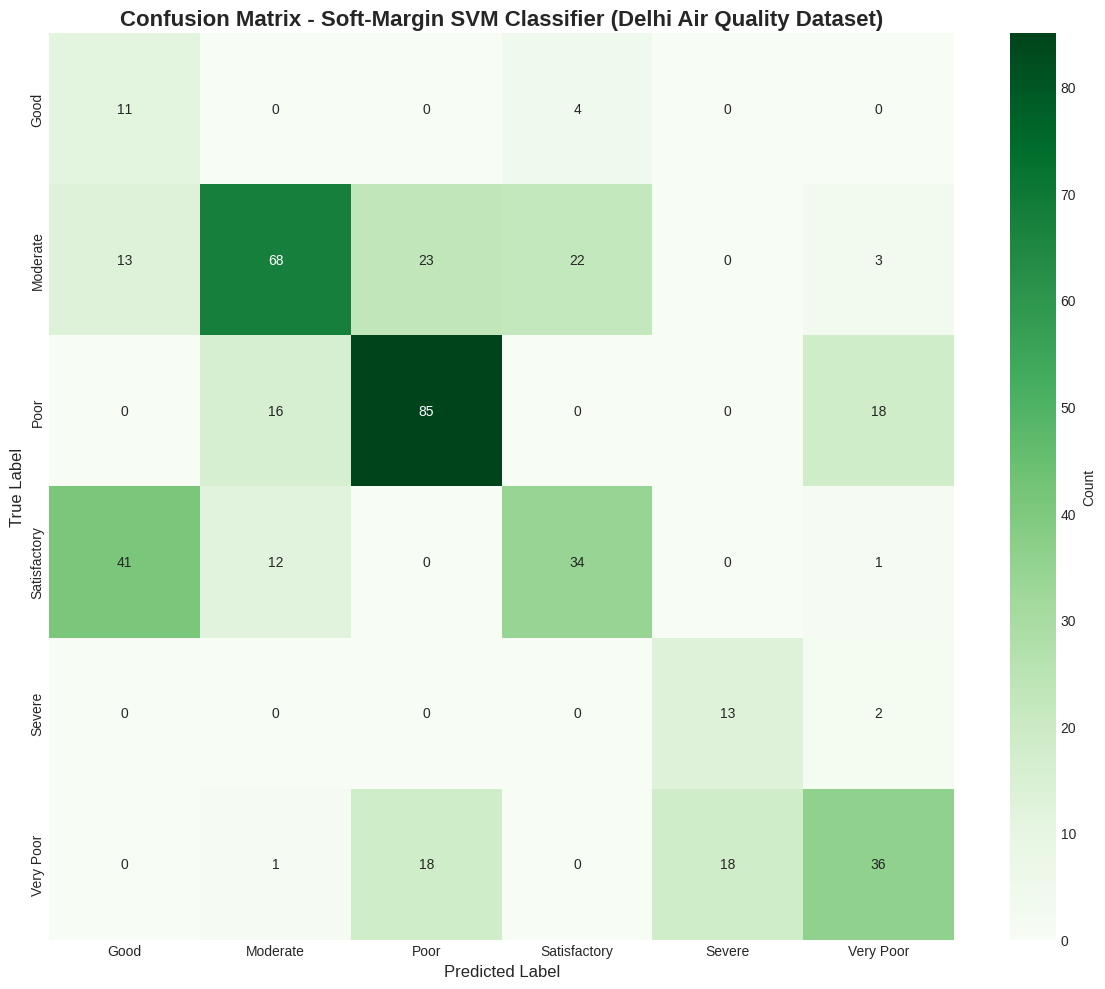

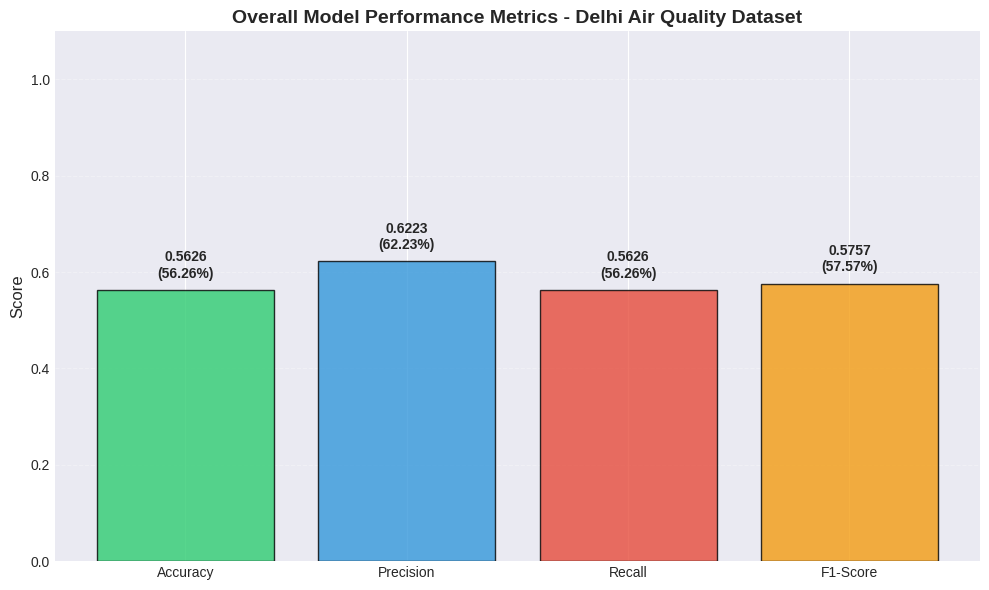

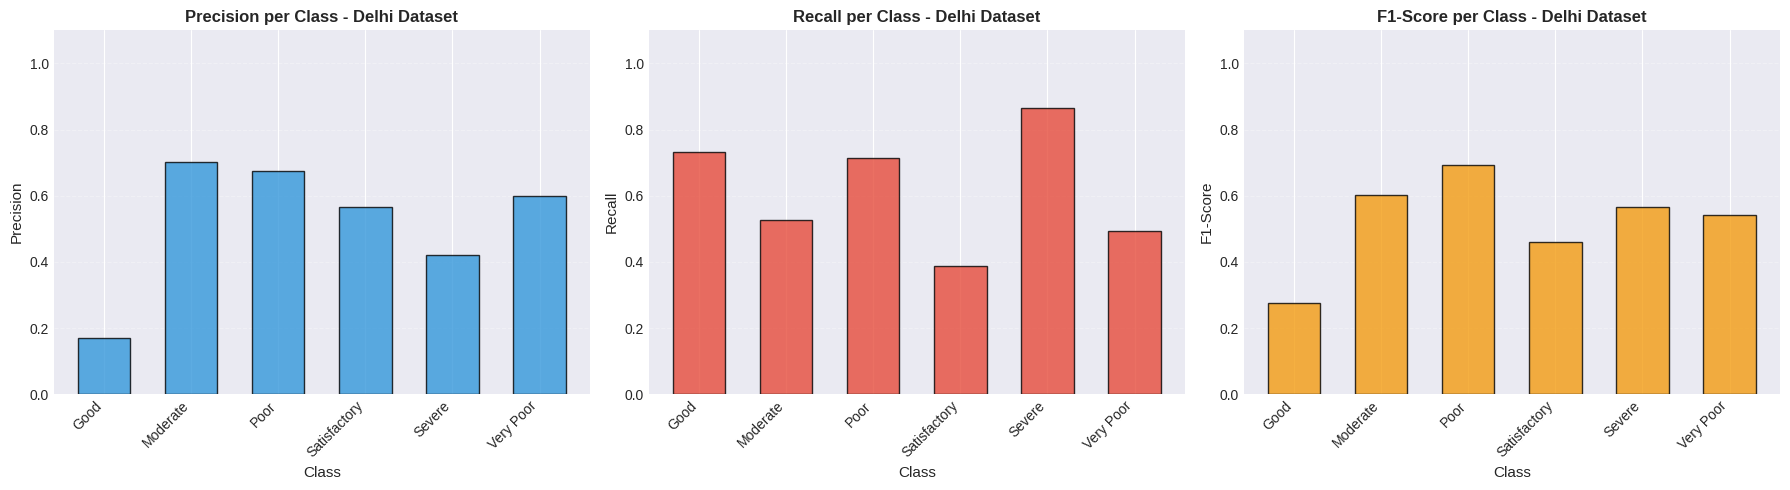

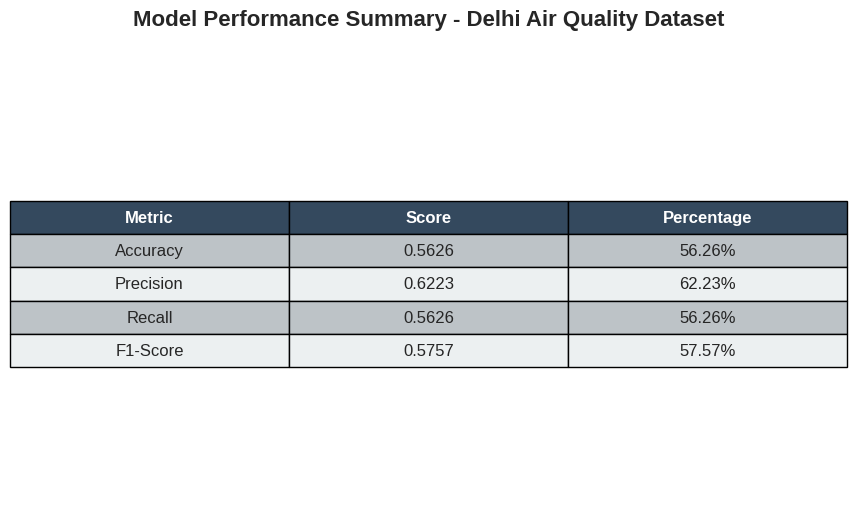

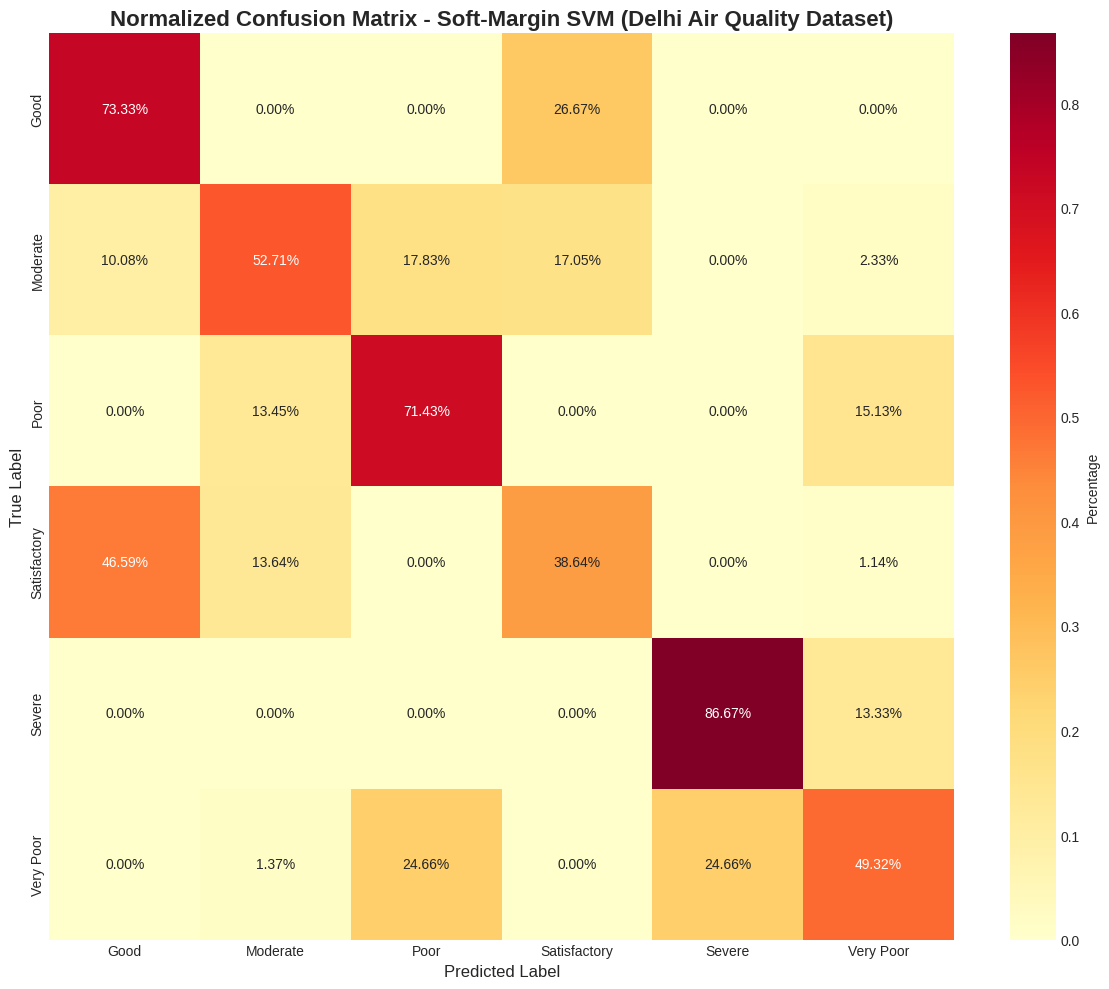

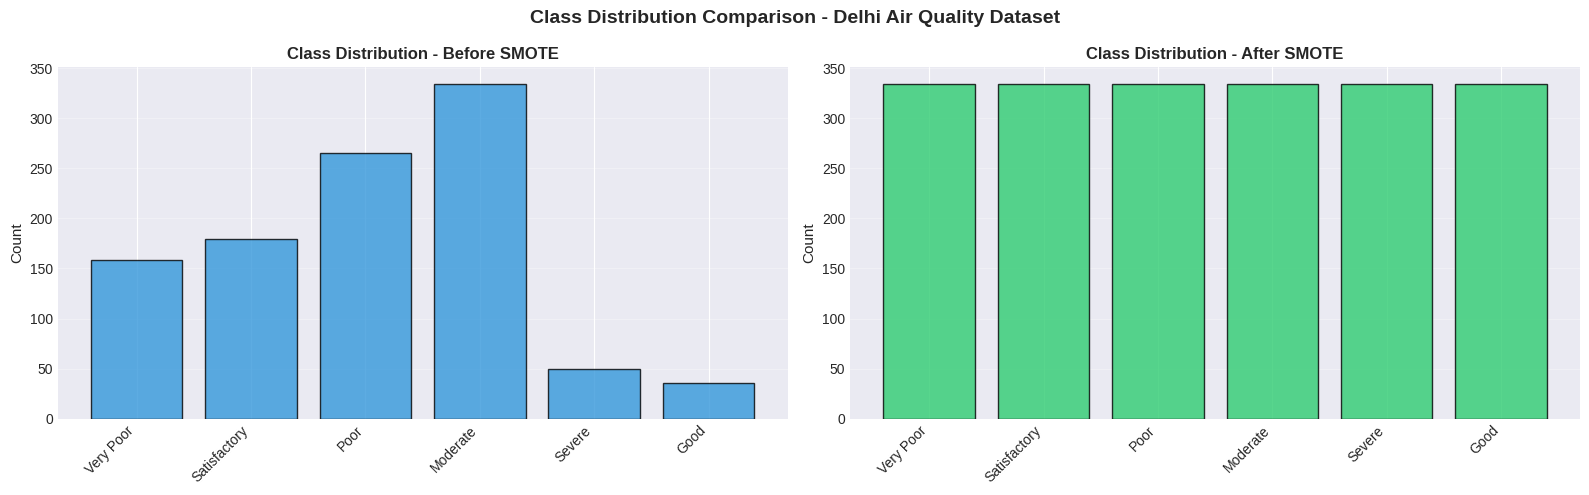


✅ EVALUATION COMPLETE - DELHI AIR QUALITY DATASET


In [9]:
# ============================================================================
# TRAINING AND EVALUATION: Delhi Air Quality Dataset
# ============================================================================

print("\n" + "="*80)
print("TRAINING SOFT-MARGIN SVM MODEL - DELHI AIR QUALITY DATASET")
print("="*80)

# Memory-efficient training: Use linear kernel for large datasets
n_samples_delhi = len(X_train_smote_delhi)
n_classes_delhi = len(np.unique(y_train_smote_delhi))
n_pairs_delhi = n_classes_delhi * (n_classes_delhi - 1) // 2

print(f"\n📊 Training Configuration:")
print(f"  Training samples: {n_samples_delhi}")
print(f"  Number of classes: {n_classes_delhi}")
print(f"  Number of binary classifiers: {n_pairs_delhi}")

# Choose kernel based on dataset size
if n_samples_delhi > 5000:
    kernel_type_delhi = 'linear'
    kernel_params_delhi = {}
    print(f"  Kernel: Linear (chosen for memory efficiency)")
else:
    kernel_type_delhi = 'rbf'
    kernel_params_delhi = {'gamma': 0.1}
    print(f"  Kernel: RBF (gamma={kernel_params_delhi['gamma']})")

# C parameter
C_value_delhi = 0.1

print(f"  C (regularization): {C_value_delhi}")
print(f"  Strategy: One-vs-One multiclass")

# Create base SVM classifier
base_svm_delhi = SoftMarginSVM(
    C=C_value_delhi,
    kernel=kernel_type_delhi,
    **kernel_params_delhi,
    verbose=True
)

# Wrap in OneVsOneClassifier
model_delhi = OneVsOneClassifier(estimator=base_svm_delhi, n_jobs=1, verbose=True)

# Train the model
print(f"\n🚀 Starting training...")
print(f"  This will train {n_pairs_delhi} binary classifiers")

try:
    model_delhi.fit(X_train_smote_delhi, y_train_smote_delhi)
    print("\n✅ Training completed!")
except MemoryError as e:
    print(f"\n❌ Memory Error during training: {e}")
    print("  Solutions:")
    print(f"  1. Reduce MAX_TRAIN_SAMPLES (currently {MAX_TRAIN_SAMPLES_DELHI})")
    print("  2. Use linear kernel only")
    print("  3. Reduce MAX_SAMPLES_PER_CLASS in SMOTE")
    raise
except Exception as e:
    print(f"\n❌ Error during training: {e}")
    raise

# Make predictions
print("\n📊 Making predictions on test set...")
y_pred_delhi = model_delhi.predict(X_test_delhi)

# Calculate metrics
accuracy_delhi = accuracy_score(y_test_delhi, y_pred_delhi)
precision_delhi = precision_score(y_test_delhi, y_pred_delhi, average='weighted', zero_division=0)
recall_delhi = recall_score(y_test_delhi, y_pred_delhi, average='weighted', zero_division=0)
f1_delhi = f1_score(y_test_delhi, y_pred_delhi, average='weighted', zero_division=0)

# Per-class metrics
precision_per_class_delhi = precision_score(y_test_delhi, y_pred_delhi, average=None, zero_division=0)
recall_per_class_delhi = recall_score(y_test_delhi, y_pred_delhi, average=None, zero_division=0)
f1_per_class_delhi = f1_score(y_test_delhi, y_pred_delhi, average=None, zero_division=0)

print("\n" + "="*80)
print("OVERALL METRICS - DELHI DATASET")
print("="*80)
print(f"  Accuracy:  {accuracy_delhi:.4f} ({accuracy_delhi*100:.2f}%)")
print(f"  Precision: {precision_delhi:.4f} ({precision_delhi*100:.2f}%)")
print(f"  Recall:    {recall_delhi:.4f} ({recall_delhi*100:.2f}%)")
print(f"  F1-Score:  {f1_delhi:.4f} ({f1_delhi*100:.2f}%)")

# Create metrics table
print("\n" + "="*80)
print("PER-CLASS METRICS - DELHI DATASET")
print("="*80)
metrics_df_delhi = pd.DataFrame({
    'Class': le_delhi.classes_,
    'Precision': precision_per_class_delhi,
    'Recall': recall_per_class_delhi,
    'F1-Score': f1_per_class_delhi
})
print("\n")
print(metrics_df_delhi.to_string(index=False))

# Classification Report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT - DELHI DATASET")
print("="*80)
print("\n")
print(classification_report(y_test_delhi, y_pred_delhi, target_names=le_delhi.classes_))

# Confusion Matrix
cm_delhi = confusion_matrix(y_test_delhi, y_pred_delhi)

# ============================================================================
# VISUALIZATIONS - DELHI DATASET
# ============================================================================

# Visualization 1: Confusion Matrix Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm_delhi, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_delhi.classes_, yticklabels=le_delhi.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Soft-Margin SVM Classifier (Delhi Air Quality Dataset)',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 2: Overall Metrics Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy_delhi, precision_delhi, recall_delhi, f1_delhi]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

bars = ax.bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylim([0, 1.1])
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Overall Model Performance Metrics - Delhi Air Quality Dataset',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{value:.4f}\n({value*100:.2f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Visualization 3: Per-Class Metrics Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_pos = np.arange(len(le_delhi.classes_))
width = 0.6

axes[0].bar(x_pos, precision_per_class_delhi, width, color='#3498db', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision per Class - Delhi Dataset', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(le_delhi.classes_, rotation=45, ha='right')
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

axes[1].bar(x_pos, recall_per_class_delhi, width, color='#e74c3c', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Recall', fontsize=11)
axes[1].set_title('Recall per Class - Delhi Dataset', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(le_delhi.classes_, rotation=45, ha='right')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

axes[2].bar(x_pos, f1_per_class_delhi, width, color='#f39c12', alpha=0.8, edgecolor='black')
axes[2].set_xlabel('Class', fontsize=11)
axes[2].set_ylabel('F1-Score', fontsize=11)
axes[2].set_title('F1-Score per Class - Delhi Dataset', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(le_delhi.classes_, rotation=45, ha='right')
axes[2].set_ylim([0, 1.1])
axes[2].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Visualization 4: Metrics Summary Table (Visual)
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')

table_data = [
    ['Metric', 'Score', 'Percentage'],
    ['Accuracy', f'{accuracy_delhi:.4f}', f'{accuracy_delhi*100:.2f}%'],
    ['Precision', f'{precision_delhi:.4f}', f'{precision_delhi*100:.2f}%'],
    ['Recall', f'{recall_delhi:.4f}', f'{recall_delhi*100:.2f}%'],
    ['F1-Score', f'{f1_delhi:.4f}', f'{f1_delhi*100:.2f}%']
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center',
                colWidths=[0.3, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

# Style the header
for i in range(3):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style the data rows
colors_table = ['#ecf0f1', '#bdc3c7']
for i in range(1, len(table_data)):
    for j in range(3):
        table[(i, j)].set_facecolor(colors_table[i % 2])

plt.title('Model Performance Summary - Delhi Air Quality Dataset', fontsize=16, fontweight='bold', pad=20)
plt.show()

# Visualization 5: Normalized Confusion Matrix
cm_normalized_delhi = cm_delhi.astype('float') / cm_delhi.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized_delhi, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=le_delhi.classes_, yticklabels=le_delhi.classes_,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - Soft-Margin SVM (Delhi Air Quality Dataset)',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 6: Class Distribution Comparison (Before/After SMOTE)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before SMOTE
y_train_delhi_counts = Counter(y_train_delhi)
axes[0].bar(range(len(y_train_delhi_counts)), list(y_train_delhi_counts.values()),
            color='#3498db', alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(y_train_delhi_counts)))
axes[0].set_xticklabels([le_delhi.classes_[i] for i in y_train_delhi_counts.keys()], rotation=45, ha='right')
axes[0].set_title('Class Distribution - Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# After SMOTE
y_train_smote_delhi_counts = Counter(y_train_smote_delhi)
axes[1].bar(range(len(y_train_smote_delhi_counts)), list(y_train_smote_delhi_counts.values()),
            color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1].set_xticks(range(len(y_train_smote_delhi_counts)))
axes[1].set_xticklabels([le_delhi.classes_[i] for i in y_train_smote_delhi_counts.keys()], rotation=45, ha='right')
axes[1].set_title('Class Distribution - After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution Comparison - Delhi Air Quality Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE - DELHI AIR QUALITY DATASET")
print("="*80)


In [10]:
# ============================================================================
# SAVE MODEL - DELHI AIR QUALITY DATASET
# ============================================================================

print("\n" + "="*80)
print("SAVING MODEL - DELHI AIR QUALITY DATASET")
print("="*80)

model_data_delhi = {
    'model': model_delhi,
    'label_encoder': le_delhi,
    'city_encoder': city_encoder_delhi,
    'scaler': scaler_delhi,
    'accuracy': accuracy_delhi,
    'precision': precision_delhi,
    'recall': recall_delhi,
    'f1_score': f1_delhi,
    'kernel': kernel_type_delhi,
    'C': C_value_delhi,
    'kernel_params': kernel_params_delhi,
    'feature_columns': feature_columns_delhi,
    'test_size': 0.3,
    'random_state': 0,
    'dataset_name': 'Delhi Air Quality Dataset'
}

# Determine output path (platform-specific)
if IS_COLAB:
    output_path_delhi = '/content/svm_model_delhi.pkl'
    if os.path.exists('/content/drive'):
        drive_path_delhi = '/content/drive/MyDrive/svm_model_delhi.pkl'
        try:
            joblib.dump(model_data_delhi, drive_path_delhi)
            print(f"   💾 Also saved to Google Drive: {drive_path_delhi}")
        except Exception as e:
            print(f"   ⚠️  Could not save to Google Drive: {e}")
elif IS_KAGGLE:
    output_path_delhi = '/kaggle/working/svm_model_delhi.pkl'
else:
    output_path_delhi = 'svm_model_delhi.pkl'

joblib.dump(model_data_delhi, output_path_delhi)
print(f"\n💾 Model saved as '{output_path_delhi}'")

print(f"\n✅ Final Model: Soft-Margin SVM (One-vs-One) - Delhi Air Quality Dataset")
print(f"✅ Kernel: {kernel_type_delhi.upper()}")
if kernel_params_delhi:
    print(f"✅ Kernel parameters: {kernel_params_delhi}")
print(f"✅ C (regularization): {C_value_delhi}")
print(f"✅ Features: {X_train_smote_delhi.shape[1]} features")
print(f"  - Feature columns: {feature_columns_delhi}")
print(f"✅ Accuracy: {accuracy_delhi:.4f} ({accuracy_delhi*100:.2f}%)")
print(f"✅ Precision: {precision_delhi:.4f} ({precision_delhi*100:.2f}%)")
print(f"✅ Recall: {recall_delhi:.4f} ({recall_delhi*100:.2f}%)")
print(f"✅ F1-Score: {f1_delhi:.4f} ({f1_delhi*100:.2f}%)")
print(f"✅ Number of classes: {len(le_delhi.classes_)}")
print(f"✅ Number of binary classifiers: {n_pairs_delhi}")

# Summary
print("\n" + "="*80)
print("MODEL SUMMARY - DELHI AIR QUALITY DATASET")
print("="*80)
print(f"Training samples: {X_train_smote_delhi.shape[0]}")
print(f"Test samples: {X_test_delhi.shape[0]}")
print(f"Number of classes: {n_classes_delhi}")
print(f"Number of binary classifiers (One-vs-One): {n_pairs_delhi}")
print(f"Kernel type: {kernel_type_delhi}")
print(f"C parameter: {C_value_delhi}")
print(f"Test size: 30%")
print(f"Preprocessing: Median imputation, StandardScaler, SMOTE (limited)")
print(f"Memory optimization: float32, sample limits applied")
print("="*80)



SAVING MODEL - DELHI AIR QUALITY DATASET

💾 Model saved as '/content/svm_model_delhi.pkl'

✅ Final Model: Soft-Margin SVM (One-vs-One) - Delhi Air Quality Dataset
✅ Kernel: RBF
✅ Kernel parameters: {'gamma': 0.1}
✅ C (regularization): 0.1
✅ Features: 10 features
  - Feature columns: ['Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']
✅ Accuracy: 0.5626 (56.26%)
✅ Precision: 0.6223 (62.23%)
✅ Recall: 0.5626 (56.26%)
✅ F1-Score: 0.5757 (57.57%)
✅ Number of classes: 6
✅ Number of binary classifiers: 15

MODEL SUMMARY - DELHI AIR QUALITY DATASET
Training samples: 2004
Test samples: 439
Number of classes: 6
Number of binary classifiers (One-vs-One): 15
Kernel type: rbf
C parameter: 0.1
Test size: 30%
Preprocessing: Median imputation, StandardScaler, SMOTE (limited)
Memory optimization: float32, sample limits applied



COMPARISON: BOTH DATASETS PERFORMANCE SUMMARY

PERFORMANCE COMPARISON TABLE


          Dataset  Accuracy  Precision   Recall  F1-Score  Train Samples  Test Samples  Features  Classes
 City Day Dataset  0.707675   0.739384 0.707675  0.706302           8000          8860        13        6
Delhi Air Quality  0.562642   0.622338 0.562642  0.575750           2004           439        10        6


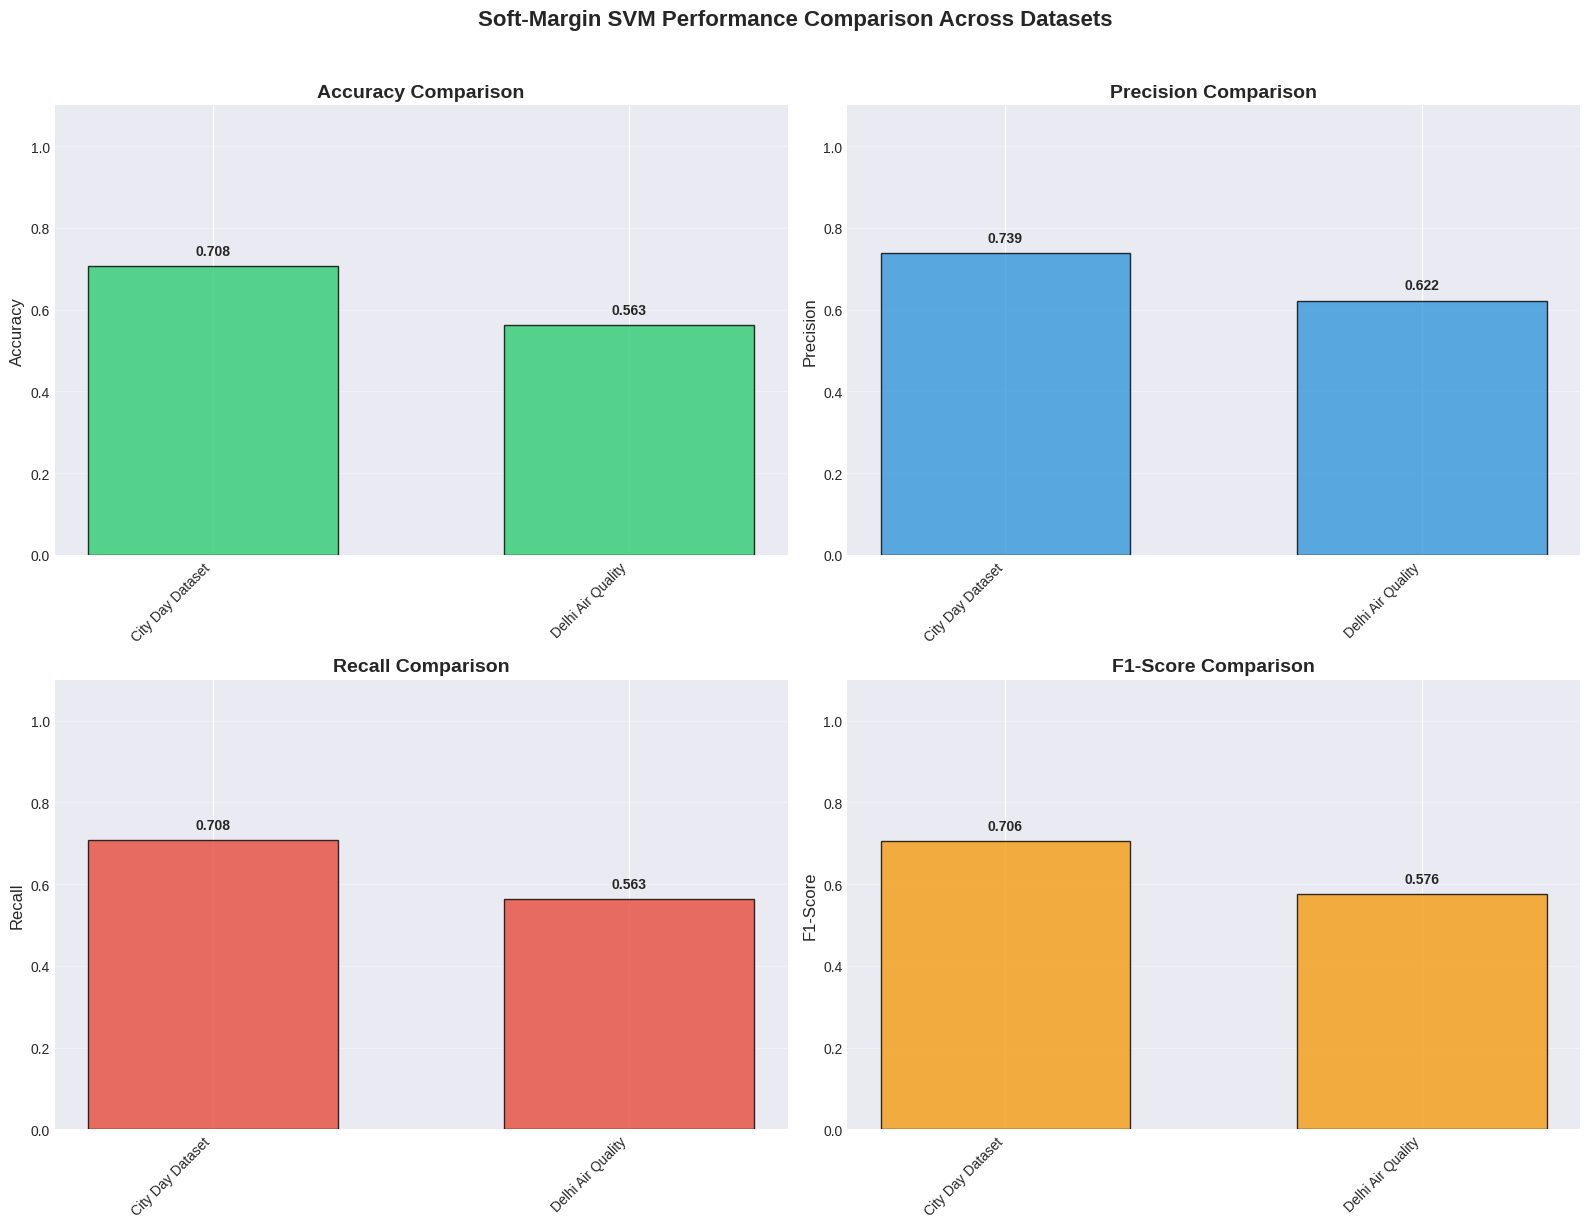

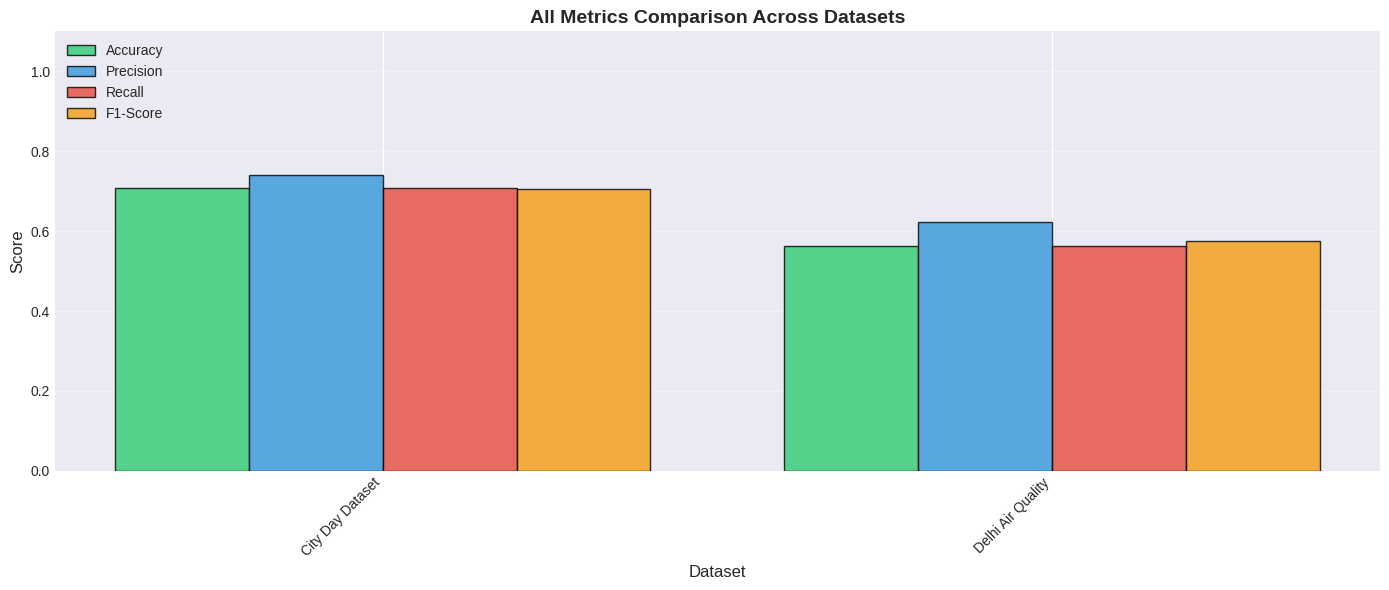

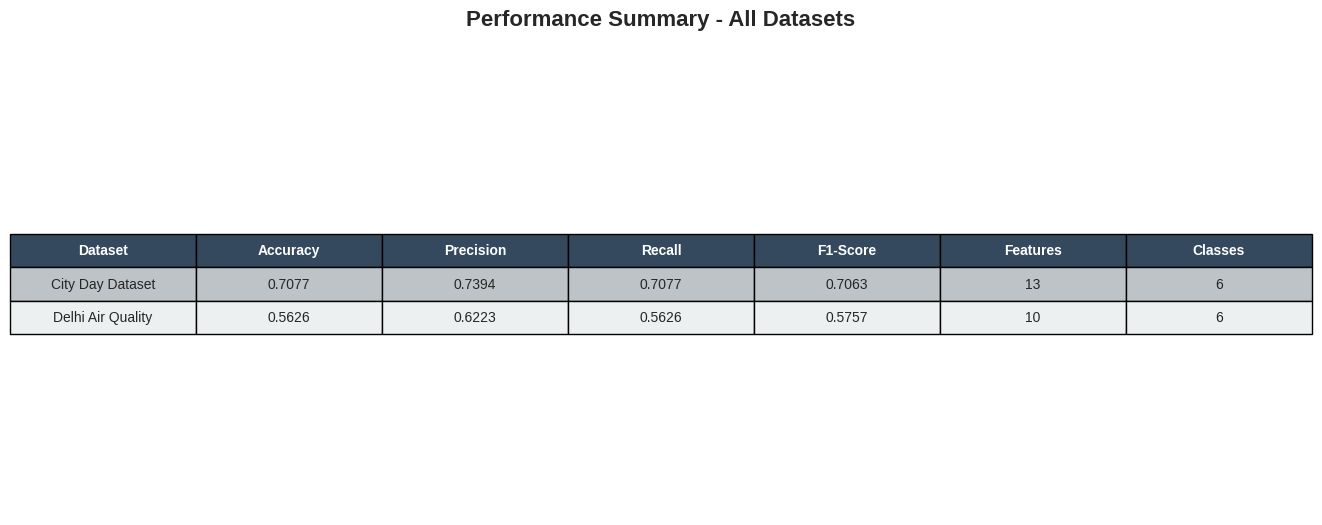


✅ COMPARISON COMPLETE


In [11]:
# ============================================================================
# COMPARISON: Both Datasets Performance Summary
# ============================================================================

print("\n" + "="*80)
print("COMPARISON: BOTH DATASETS PERFORMANCE SUMMARY")
print("="*80)

# Collect results from both datasets
results_summary = []

# City Day Dataset
try:
    results_summary.append({
        'Dataset': 'City Day Dataset',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Train Samples': len(X_train_smote),
        'Test Samples': len(X_test),
        'Features': len(feature_columns),
        'Classes': len(le.classes_)
    })
except:
    pass

# Delhi Dataset
try:
    results_summary.append({
        'Dataset': 'Delhi Air Quality',
        'Accuracy': accuracy_delhi,
        'Precision': precision_delhi,
        'Recall': recall_delhi,
        'F1-Score': f1_delhi,
        'Train Samples': len(X_train_smote_delhi),
        'Test Samples': len(X_test_delhi),
        'Features': len(feature_columns_delhi),
        'Classes': len(le_delhi.classes_)
    })
except:
    pass

if results_summary:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(results_summary)

    print("\n" + "="*80)
    print("PERFORMANCE COMPARISON TABLE")
    print("="*80)
    print("\n")
    print(comparison_df.to_string(index=False))

    # Visualization: Comparison Bar Chart
    if len(results_summary) > 1:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        datasets = comparison_df['Dataset'].values
        x_pos = np.arange(len(datasets))
        width = 0.6

        # Accuracy comparison
        axes[0, 0].bar(x_pos, comparison_df['Accuracy'], width, color='#2ecc71', alpha=0.8, edgecolor='black')
        axes[0, 0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
        axes[0, 0].set_ylabel('Accuracy', fontsize=12)
        axes[0, 0].set_xticks(x_pos)
        axes[0, 0].set_xticklabels(datasets, rotation=45, ha='right')
        axes[0, 0].set_ylim([0, 1.1])
        axes[0, 0].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comparison_df['Accuracy']):
            axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

        # Precision comparison
        axes[0, 1].bar(x_pos, comparison_df['Precision'], width, color='#3498db', alpha=0.8, edgecolor='black')
        axes[0, 1].set_title('Precision Comparison', fontsize=14, fontweight='bold')
        axes[0, 1].set_ylabel('Precision', fontsize=12)
        axes[0, 1].set_xticks(x_pos)
        axes[0, 1].set_xticklabels(datasets, rotation=45, ha='right')
        axes[0, 1].set_ylim([0, 1.1])
        axes[0, 1].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comparison_df['Precision']):
            axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

        # Recall comparison
        axes[1, 0].bar(x_pos, comparison_df['Recall'], width, color='#e74c3c', alpha=0.8, edgecolor='black')
        axes[1, 0].set_title('Recall Comparison', fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('Recall', fontsize=12)
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(datasets, rotation=45, ha='right')
        axes[1, 0].set_ylim([0, 1.1])
        axes[1, 0].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comparison_df['Recall']):
            axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

        # F1-Score comparison
        axes[1, 1].bar(x_pos, comparison_df['F1-Score'], width, color='#f39c12', alpha=0.8, edgecolor='black')
        axes[1, 1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylabel('F1-Score', fontsize=12)
        axes[1, 1].set_xticks(x_pos)
        axes[1, 1].set_xticklabels(datasets, rotation=45, ha='right')
        axes[1, 1].set_ylim([0, 1.1])
        axes[1, 1].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comparison_df['F1-Score']):
            axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

        plt.suptitle('Soft-Margin SVM Performance Comparison Across Datasets',
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        # Combined metrics comparison
        fig, ax = plt.subplots(figsize=(14, 6))
        x = np.arange(len(datasets))
        width = 0.2

        metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
        colors_combined = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

        for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_combined)):
            offset = (i - 1.5) * width
            ax.bar(x + offset, comparison_df[metric], width, label=metric,
                  color=color, alpha=0.8, edgecolor='black')

        ax.set_xlabel('Dataset', fontsize=12)
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title('All Metrics Comparison Across Datasets', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=45, ha='right')
        ax.set_ylim([0, 1.1])
        ax.legend(loc='upper left')
        ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Summary table visualization
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.axis('tight')
        ax.axis('off')

        # Prepare table data
        table_data = [['Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Features', 'Classes']]
        for _, row in comparison_df.iterrows():
            table_data.append([
                row['Dataset'],
                f"{row['Accuracy']:.4f}",
                f"{row['Precision']:.4f}",
                f"{row['Recall']:.4f}",
                f"{row['F1-Score']:.4f}",
                str(int(row['Features'])),
                str(int(row['Classes']))
            ])

        table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                        cellLoc='center', loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 2)

        # Style the header
        for i in range(len(table_data[0])):
            table[(0, i)].set_facecolor('#34495e')
            table[(0, i)].set_text_props(weight='bold', color='white')

        # Style the data rows
        colors_table = ['#ecf0f1', '#bdc3c7']
        for i in range(1, len(table_data)):
            for j in range(len(table_data[0])):
                table[(i, j)].set_facecolor(colors_table[i % 2])

        plt.title('Performance Summary - All Datasets', fontsize=16, fontweight='bold', pad=20)
        plt.show()

    print("\n" + "="*80)
    print("✅ COMPARISON COMPLETE")
    print("="*80)
else:
    print("\n⚠️  No datasets were successfully processed for comparison.")
